In [18]:
import os

ROOT = "/kaggle/input/datasets/mrithulavjmp/crowd-prediction"

if not os.path.exists(ROOT):
    print(f"[!] {ROOT} not found. Contents of /kaggle/input:")
    for dp, dn, fn in os.walk("/kaggle/input"):
        depth = dp.replace("/kaggle/input", "").count(os.sep)
        if depth <= 3:
            print(dp)
    raise SystemExit("Fix ROOT above and re-run.")

# 1) Recursive listing with sizes
all_files = []
for dirpath, dirnames, filenames in os.walk(ROOT):
    for f in sorted(filenames):
        full = os.path.join(dirpath, f)
        all_files.append(full)

print(f"Total files found: {len(all_files)}\n")
for p in all_files:
    print(f"{os.path.getsize(p)/1024:>12,.1f} KB  {p}")

# 2) Identify key files by name (case-insensitive)
def find(pattern, ext=None):
    hits = [p for p in all_files
            if pattern in os.path.basename(p).lower()
            and (ext is None or p.lower().endswith(ext))]
    return hits

paths = {
    "boarding": find("boarding", ".csv"),
    "landing":  find("landing", ".csv"),
    "loader":   find("loader", ".csv"),
}
gtfs_names = ["stops", "stop_times", "trips", "routes",
              "calendar", "calendar_dates", "shapes"]
for g in gtfs_names:
    paths[f"gtfs_{g}"] = [p for p in all_files
                          if os.path.basename(p).lower() == f"{g}.txt"]

print("\n" + "="*70)
print("IDENTIFIED FILES")
print("="*70)
for k, v in paths.items():
    if len(v) == 0:
        print(f"{k:<20} -> NOT FOUND")
    elif len(v) == 1:
        print(f"{k:<20} -> {v[0]}")
    else:
        print(f"{k:<20} -> MULTIPLE MATCHES ({len(v)}):")
        for x in v:
            print(f"{'':<23}{x}")

# 3) Other files that were not matched (so nothing is missed)
matched = {x for v in paths.values() for x in v}
others = [p for p in all_files if p not in matched]
print(f"\nOther files not matched above: {len(others)}")
for p in others:
    print("  ", p)

Total files found: 19

         6.5 KB  /kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2/README.md
       919.7 KB  /kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2/boarding_03-05_2024.csv
       901.5 KB  /kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2/landing_03-05_2024.csv
     1,020.6 KB  /kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2/loader_03-05_2024.csv
         0.2 KB  /kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2/GTFS/agency.txt
        49.1 KB  /kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2/GTFS/calendar.txt
         0.0 KB  /kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2/GTFS/calendar_dates.txt
         0.1 KB  /kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2/GTFS/fare_attributes.txt
         0.1 KB  /kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2/GTFS/fare_rules.txt
         0.2 KB  /kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2/GTFS/feed_info.txt
      

In [50]:
import json
import os

SAVED = "/kaggle/input/notebooks/mrithulavjmp/st-gcn-crowd-prediction-model"
WORK = "/kaggle/working"

mc = json.load(open(f"{SAVED}/model_config.json"))
fc = json.load(open(f"{SAVED}/feature_config.json"))
ti = json.load(open(f"{SAVED}/training_info.json"))

MODEL_PATH = f"{SAVED}/best_stgcn_crowd_model.pt"

print("Saved Version 1 files loaded successfully")
print("Model path:", MODEL_PATH)
print("New outputs will be saved to:", WORK)

Saved Version 1 files loaded successfully
Model path: /kaggle/input/notebooks/mrithulavjmp/st-gcn-crowd-prediction-model/best_stgcn_crowd_model.pt
New outputs will be saved to: /kaggle/working


In [19]:
import pandas as pd
import numpy as np

BASE = "/kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2"
CROWD_PATHS = {
    "boarding": f"{BASE}/boarding_03-05_2024.csv",
    "landing":  f"{BASE}/landing_03-05_2024.csv",
    "loader":   f"{BASE}/loader_03-05_2024.csv",
}

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# 1) README
print("=" * 70)
print("README.md")
print("=" * 70)
with open(f"{BASE}/README.md", "r", encoding="utf-8", errors="replace") as f:
    print(f.read())

# 2) Helper for inspection (reused in later cells)
def inspect_df(df, name, n_unique_show=5):
    print("\n" + "=" * 70)
    print(f"{name.upper()}")
    print("=" * 70)
    print("Shape:", df.shape)
    print("\nColumns:", list(df.columns))
    print("\nDtypes:")
    print(df.dtypes.to_string())
    print("\nFirst 5 rows:")
    print(df.head())
    print("\nNull counts:")
    print(df.isnull().sum().to_string())
    print("\nFully duplicated rows:", df.duplicated().sum())
    print("\nColumn summary:")
    for c in df.columns:
        nun = df[c].nunique(dropna=True)
        sample = df[c].dropna().unique()[:n_unique_show].tolist()
        print(f"  {c:<30} unique={nun:<8} sample={sample}")
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] > 0:
        print("\nNumeric describe:")
        print(num.describe().T.to_string())

# 3) Load safely
crowd_raw = {}
for k, p in CROWD_PATHS.items():
    try:
        crowd_raw[k] = pd.read_csv(p)
    except Exception as e:
        print(f"[!] Failed to load {k}: {e}")

for k, df in crowd_raw.items():
    inspect_df(df, k)

README.md
# Public Transport Time Series

## Overview

This dataset provides time series data on estimated boardings, landings, and bus occupancy (loader) across selected stops in the public transport network. The data is aggregated in 5-minute intervals and was generated through the integration and analysis of multiple transport data sources.

- **Boarding data** was extracted using data mining techniques from **Automatic Vehicle Location (AVL)**, **Automatic Fare Collection (AFC)**, and **General Transit Feed Specification (GTFS)** systems.  
- **Alighting data** was estimated using the **trip chaining** method.  
- **Bus occupancy** was calculated based on the ratio of boardings and alightings per vehicle.

The full SUNT dataset is available on [GITHUB](https://github.com/LabIA-UFBA/SUNT#).

### Available datasets:

- [boarding_03-05_2024.csv](boarding_03-05_2024.csv): Estimated boardings per stop  
- [landing_03-05_2024.csv](landing_03-05_2024.csv): Estimated alightings per stop  


In [20]:
import pandas as pd
import numpy as np

GTFS = "/kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2/GTFS"

def load_gtfs(name):
    path = f"{GTFS}/{name}.txt"
    try:
        return pd.read_csv(path, dtype=str, low_memory=False)
    except pd.errors.EmptyDataError:
        print(f"[!] {name}.txt is empty")
        return pd.DataFrame()

gtfs = {n: load_gtfs(n) for n in
        ["stops", "stop_times", "trips", "routes", "calendar", "calendar_dates", "shapes"]}

for name, df in gtfs.items():
    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)
    print("Shape:", df.shape)
    if df.empty:
        continue
    print("Columns:", list(df.columns))
    print("\nFirst 5 rows:")
    print(df.head().to_string())
    print("\nNull counts (only columns with nulls):")
    nulls = df.isnull().sum()
    print(nulls[nulls > 0].to_string() if (nulls > 0).any() else "  none")
    print("Fully duplicated rows:", df.duplicated().sum())

# ---- Graph-relevant checks ----
stops, st, trips, routes = gtfs["stops"], gtfs["stop_times"], gtfs["trips"], gtfs["routes"]

print("\n" + "=" * 70)
print("GRAPH-RELEVANT CHECKS")
print("=" * 70)
print("Unique stop_id in stops.txt      :", stops["stop_id"].nunique())
print("Unique stop_id in stop_times.txt :", st["stop_id"].nunique())
print("stop_times stops missing in stops.txt:",
      len(set(st["stop_id"]) - set(stops["stop_id"])))
print("stops.txt stops never used in stop_times:",
      len(set(stops["stop_id"]) - set(st["stop_id"])))
print("Unique trips in trips.txt        :", trips["trip_id"].nunique())
print("Unique trips in stop_times.txt   :", st["trip_id"].nunique())
print("Unique routes                    :", routes["route_id"].nunique())

if "location_type" in stops.columns:
    print("\nlocation_type counts:")
    print(stops["location_type"].value_counts(dropna=False).to_string())
if "parent_station" in stops.columns:
    print("Stops with parent_station:", stops["parent_station"].notnull().sum())
if "direction_id" in trips.columns:
    print("\ndirection_id counts:")
    print(trips["direction_id"].value_counts(dropna=False).to_string())

st["stop_sequence"] = pd.to_numeric(st["stop_sequence"], errors="coerce")
print("\nstop_sequence non-numeric:", st["stop_sequence"].isnull().sum())
print("Stops per trip (describe):")
print(st.groupby("trip_id").size().describe().to_string())

if "arrival_time" in st.columns:
    print("\nSample arrival_time values:", st["arrival_time"].dropna().unique()[:5].tolist())
    over24 = st["arrival_time"].dropna().str[:2].astype(int) >= 24
    print("arrival_time with hour >= 24:", int(over24.sum()))

if not gtfs["calendar"].empty:
    cal = gtfs["calendar"]
    print("\nCalendar start_date range:", cal["start_date"].min(), "->", cal["start_date"].max())
    print("Calendar end_date range  :", cal["end_date"].min(), "->", cal["end_date"].max())


STOPS
Shape: (2975, 9)
Columns: ['stop_id', 'stop_name', 'stop_desc', 'stop_lat', 'stop_lon', 'zone_id', 'stop_url', 'location_type', 'parent_station']

First 5 rows:
      stop_id                                                                        stop_name         stop_desc           stop_lat           stop_lon zone_id stop_url location_type parent_station
0  43968810_S                   R. São Cristóvão 2 - Sussuarana Salvador - BA 41213-430 Brasil  SUSSUARANA VELHA   -12.931565284729   -38.444393157959     NaN      NaN             1            NaN
1    43968810                   R. São Cristóvão 2 - Sussuarana Salvador - BA 41213-430 Brasil  SUSSUARANA VELHA   -12.931565284729   -38.444393157959     NaN      NaN             0     43968810_S
2  47566106_S           Av. Ulysses Guimarães 4067 - Sussuarana Salvador - BA 41213-000 Brasil               NaN    -12.93385887146  -38.4467735290527     NaN      NaN             1            NaN
3    47566106           Av. Ulysses Guimarãe

In [21]:
import pandas as pd
import numpy as np

BASE = "/kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2"
GTFS = f"{BASE}/GTFS"

# ---------- 1) Load crowd files, set timestamp index ----------
def load_crowd(name):
    df = pd.read_csv(f"{BASE}/{name}_03-05_2024.csv")
    df = df.rename(columns={"Unnamed: 0": "timestamp"})
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df

raw = {n: load_crowd(n) for n in ["boarding", "landing", "loader"]}

print("=" * 70)
print("BASIC SUMMARY")
print("=" * 70)
for n, df in raw.items():
    stops_n = [c for c in df.columns if c != "timestamp"]
    print(f"{n:<9} rows={len(df):,}  stops={len(stops_n)}  "
          f"range={df['timestamp'].min()} -> {df['timestamp'].max()}  "
          f"dup_timestamps={df['timestamp'].duplicated().sum()}  "
          f"sorted={df['timestamp'].is_monotonic_increasing}")

# ---------- 2) Same stops / same timestamps across files ----------
cols = {n: set(c for c in df.columns if c != "timestamp") for n, df in raw.items()}
ts = {n: set(df["timestamp"]) for n, df in raw.items()}
print("\nSame stop columns in all 3 files :", cols["boarding"] == cols["landing"] == cols["loader"])
print("Same timestamps in all 3 files   :", ts["boarding"] == ts["landing"] == ts["loader"])
print("Same row order (boarding vs landing vs loader):",
      raw["boarding"]["timestamp"].equals(raw["landing"]["timestamp"]) and
      raw["boarding"]["timestamp"].equals(raw["loader"]["timestamp"]))

STOPS = sorted(cols["boarding"])
print("Crowd stop IDs:", STOPS)

# ---------- 3) Interval check ----------
t = raw["boarding"]["timestamp"].sort_values().reset_index(drop=True)
diffs = t.diff().dropna()
print("\n" + "=" * 70)
print("INTERVAL CHECK")
print("=" * 70)
print("Gap between consecutive rows (value counts):")
print(diffs.value_counts().head(10).to_string())

full_idx = pd.date_range(t.min(), t.max(), freq="5min")
print(f"\nExpected timestamps if continuous 5-min : {len(full_idx):,}")
print(f"Actual timestamps                       : {len(t):,}")
print(f"Missing intervals vs continuous grid    : {len(full_idx) - len(t):,}")
print(f"Timestamps not on a 5-minute boundary   : {(t.dt.minute % 5 != 0).sum()}")

# Daily structure (the grid may have a nightly break)
d = raw["boarding"].assign(date=lambda x: x["timestamp"].dt.date)
per_day = d.groupby("date").size()
print("\nTimestamps per calendar date (value counts):")
print(per_day.value_counts().sort_index().to_string())
print("Number of calendar dates:", per_day.shape[0])
tod = raw["boarding"]["timestamp"].dt
print("Hours present (hour of day):", sorted(tod.hour.unique().tolist()))
print("First timestamp of day (most common):",
      d.groupby("date")["timestamp"].min().dt.time.value_counts().head(3).to_dict())
print("Last  timestamp of day (most common):",
      d.groupby("date")["timestamp"].max().dt.time.value_counts().head(3).to_dict())

all_dates = pd.date_range(t.min().normalize(), t.max().normalize(), freq="D").date
missing_dates = sorted(set(all_dates) - set(per_day.index))
print("Calendar dates missing completely:", missing_dates if missing_dates else "none")

# ---------- 4) Value checks per stop ----------
print("\n" + "=" * 70)
print("VALUE CHECKS PER STOP (negatives / % zeros / constant columns)")
print("=" * 70)
rows = []
for s in STOPS:
    r = {"stop": s}
    for n in raw:
        v = raw[n][s]
        r[f"{n}_neg"] = int((v < 0).sum())
        r[f"{n}_zero%"] = round(100 * (v == 0).mean(), 1)
        r[f"{n}_max"] = int(v.max())
    rows.append(r)
print(pd.DataFrame(rows).to_string(index=False))

# ---------- 5) How is loader related to boarding/landing? ----------
print("\n" + "=" * 70)
print("LOADER vs BOARDING/LANDING RELATIONSHIP (per stop)")
print("=" * 70)
rel = []
for s in STOPS:
    b, l, o = raw["boarding"][s], raw["landing"][s], raw["loader"][s]
    net = b - l
    rel.append({
        "stop": s,
        "corr(load,board)": round(o.corr(b), 3),
        "corr(load,land)": round(o.corr(l), 3),
        "corr(dLoad,net)": round(o.diff().corr(net), 3),
        "load_mean": round(o.mean(), 1),
        "board_mean": round(b.mean(), 2),
        "land_mean": round(l.mean(), 2),
    })
print(pd.DataFrame(rel).to_string(index=False))
print("\nNote: dLoad = change in loader between consecutive rows; net = boarding - landing.")
print("Corr(dLoad, net) near 1 would mean loader is a running total; low values mean it is not.")

# ---------- 6) The 10 stops inside GTFS ----------
print("\n" + "=" * 70)
print("CROWD STOPS vs GTFS")
print("=" * 70)
stops_g = pd.read_csv(f"{GTFS}/stops.txt", dtype=str, usecols=["stop_id", "stop_name", "location_type", "stop_lat", "stop_lon"])
st = pd.read_csv(f"{GTFS}/stop_times.txt", dtype=str, usecols=["trip_id", "stop_id", "stop_sequence"])
trips = pd.read_csv(f"{GTFS}/trips.txt", dtype=str, usecols=["trip_id", "route_id", "direction_id"])

gtfs_ids = set(stops_g["stop_id"])
matched = [s for s in STOPS if s in gtfs_ids]
unmatched = [s for s in STOPS if s not in gtfs_ids]
used_ids = set(st["stop_id"])
print(f"Crowd stops matched to GTFS stops.txt : {len(matched)}/{len(STOPS)}")
print(f"Crowd stops NOT in GTFS               : {unmatched if unmatched else 'none'}")
print(f"Matched stops that appear in stop_times: {len([s for s in matched if s in used_ids])}/{len(matched)}")
print(f"GTFS stops with no crowd data         : {len(used_ids - set(STOPS)):,}")

# trips and routes per crowd stop
st["stop_sequence"] = pd.to_numeric(st["stop_sequence"])
st = st.sort_values(["trip_id", "stop_sequence"]).reset_index(drop=True)
st["pos"] = st.groupby("trip_id").cumcount()
sub = st[st["stop_id"].isin(STOPS)].merge(trips, on="trip_id", how="left")

info = []
for s in STOPS:
    x = sub[sub["stop_id"] == s]
    nm = stops_g.loc[stops_g["stop_id"] == s, "stop_name"]
    info.append({"stop": s, "trips": x["trip_id"].nunique(), "routes": x["route_id"].nunique(),
                 "name": (nm.iloc[0][:45] if len(nm) else "-")})
print("\nService at each crowd stop:")
print(pd.DataFrame(info).to_string(index=False))

# links between crowd stops
print("\n" + "=" * 70)
print("CONNECTIONS AMONG THE 10 CROWD STOPS (from GTFS trips)")
print("=" * 70)
route_sets = {s: set(sub.loc[sub["stop_id"] == s, "route_id"]) for s in STOPS}
shared_routes = pd.DataFrame(0, index=STOPS, columns=STOPS)
for a in STOPS:
    for b in STOPS:
        shared_routes.loc[a, b] = len(route_sets[a] & route_sets[b])
print("Number of shared routes (diagonal = routes at that stop):")
print(shared_routes.to_string())

pairs = sub[["trip_id", "stop_id", "pos"]]
m = pairs.merge(pairs, on="trip_id", suffixes=("_a", "_b"))
m = m[(m["stop_id_a"] != m["stop_id_b"]) & (m["pos_b"] > m["pos_a"])]
m["hops"] = m["pos_b"] - m["pos_a"]
if len(m):
    agg = m.groupby(["stop_id_a", "stop_id_b"]).agg(shared_trips=("trip_id", "nunique"),
                                                    min_hops=("hops", "min")).reset_index()
    print("\nPairs that appear on the same trip (min_hops=1 means directly consecutive):")
    print(agg.sort_values("shared_trips", ascending=False).to_string(index=False))
    print("\nDirect consecutive-stop edges among the 10:", int((agg["min_hops"] == 1).sum()))
else:
    print("\nNo two of the 10 stops share a trip.")

BASIC SUMMARY
boarding  rows=21,840  stops=10  range=2024-03-01 05:00:00 -> 2024-05-31 00:55:00  dup_timestamps=0  sorted=True
landing   rows=21,840  stops=10  range=2024-03-01 05:00:00 -> 2024-05-31 00:55:00  dup_timestamps=0  sorted=True
loader    rows=21,840  stops=10  range=2024-03-01 05:00:00 -> 2024-05-31 00:55:00  dup_timestamps=0  sorted=True

Same stop columns in all 3 files : True
Same timestamps in all 3 files   : True
Same row order (boarding vs landing vs loader): True
Crowd stop IDs: ['125960550', '230565994', '258781031', '43768720', '44072192', '44783654', '44783914', '44784438', '45833547', '47568123']

INTERVAL CHECK
Gap between consecutive rows (value counts):
timestamp
0 days 00:05:00    21749
0 days 04:05:00       90

Expected timestamps if continuous 5-min : 26,160
Actual timestamps                       : 21,840
Missing intervals vs continuous grid    : 4,320
Timestamps not on a 5-minute boundary   : 0

Timestamps per calendar date (value counts):
12      1
228  

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Crowd stops matched to GTFS stops.txt : 10/10
Crowd stops NOT in GTFS               : none
Matched stops that appear in stop_times: 10/10
GTFS stops with no crowd data         : 2,857

Service at each crowd stop:
     stop  trips  routes                                          name
125960550    251       5 R. Artêmio Castro Valente 11 - Canabrava Salv
230565994    192       3 Rua Professor Souza Brito 143 Salvador - Bahi
258781031   4277      48                            ESTAÇÃO RODOVIÁRIA
 43768720  10303      64 Avenida Vale Do Tororo 327 Salvador - Bahia 4
 44072192    631       9 Largo Campo Grande 584 Salvador - Bahia 40080
 44783654   1101       7 Av. Adhemar de Barros S/N - Universidade Fede
 44783914   1828      39 Rua da Conceição da Praia - Comercio Salvador
 44784438   1443      18 Avenida Vasco da Gama 4274 - Brotas Salvador 
 45833547    401      10 Av. Eng. Oscar Pontes 2015-2127 - Calçada Sal
 47568123   1112      14 Av. Centenário 2761 - Chame-Chame Salvador - 

CONNE

In [22]:
import os
import numpy as np
import pandas as pd

BASE = "/kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2"
GTFS = f"{BASE}/GTFS"
OUT = "/kaggle/working"
os.makedirs(OUT, exist_ok=True)

# Node order = column order of the crowd files (fixed from now on)
STOPS = [c for c in pd.read_csv(f"{BASE}/boarding_03-05_2024.csv", nrows=0).columns
         if c != "Unnamed: 0"]
N = len(STOPS)
stop_to_idx = {s: i for i, s in enumerate(STOPS)}

stops_g = pd.read_csv(f"{GTFS}/stops.txt", dtype=str,
                      usecols=["stop_id", "stop_name", "stop_lat", "stop_lon", "location_type"])
st = pd.read_csv(f"{GTFS}/stop_times.txt", dtype=str,
                 usecols=["trip_id", "stop_id", "stop_sequence"])
st["stop_sequence"] = pd.to_numeric(st["stop_sequence"])
st = st.sort_values(["trip_id", "stop_sequence"]).reset_index(drop=True)

# ---------- A) Full-network graph: statistics only (consecutive stops) ----------
nxt = st.groupby("trip_id")["stop_id"].shift(-1)
full = pd.DataFrame({"a": st["stop_id"], "b": nxt}).dropna()
full = full[full["a"] != full["b"]]
full["u"] = np.where(full["a"] < full["b"], full["a"], full["b"])
full["v"] = np.where(full["a"] < full["b"], full["b"], full["a"])
full_edges = full[["u", "v"]].drop_duplicates()
full_nodes = st["stop_id"].nunique()
deg = pd.concat([full_edges["u"], full_edges["v"]]).value_counts()

print("=" * 70)
print("FULL GTFS NETWORK (reference only, not used for training)")
print("=" * 70)
print("Nodes (stops used in stop_times):", full_nodes)
print("Undirected edges (consecutive stops):", len(full_edges))
print("Average degree:", round(2 * len(full_edges) / full_nodes, 2))
print("Isolated stops:", full_nodes - deg.shape[0])

# ---------- B) Crowd graph: consecutive CROWD stops along each trip ----------
c = st[st["stop_id"].isin(STOPS)].copy()           # already sorted by trip, sequence
c["next_stop"] = c.groupby("trip_id")["stop_id"].shift(-1)
pairs = c.dropna(subset=["next_stop"])
pairs = pairs[pairs["stop_id"] != pairs["next_stop"]]
pairs = pairs.assign(
    u=np.where(pairs["stop_id"] < pairs["next_stop"], pairs["stop_id"], pairs["next_stop"]),
    v=np.where(pairs["stop_id"] < pairs["next_stop"], pairs["next_stop"], pairs["stop_id"]),
)
# one vote per trip per pair (a trip passing the same pair twice counts once)
edge_w = (pairs.drop_duplicates(["trip_id", "u", "v"])
               .groupby(["u", "v"])["trip_id"].nunique()
               .rename("trips").reset_index())

print("\n" + "=" * 70)
print("CROWD-STOP GRAPH EDGES (supporting trips)")
print("=" * 70)
print(edge_w.sort_values("trips", ascending=False).to_string(index=False))

# ---------- C) Weighted adjacency + normalization ----------
W = np.zeros((N, N), dtype=np.float64)
for _, r in edge_w.iterrows():
    i, j = stop_to_idx[r["u"]], stop_to_idx[r["v"]]
    W[i, j] = W[j, i] = r["trips"]

A = np.log1p(W)
A = A / A.max()                         # edge weights in (0, 1]
A_hat = A + np.eye(N)                   # self-loops
d = A_hat.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(d))
A_norm = (D_inv_sqrt @ A_hat @ D_inv_sqrt).astype(np.float32)

n_edges = int((W > 0).sum() // 2)
deg_c = (W > 0).sum(axis=1)
print("\n" + "=" * 70)
print("CROWD GRAPH STATISTICS")
print("=" * 70)
print("Nodes:", N)
print("Undirected edges (excluding self-loops):", n_edges)
print("Average degree:", round(deg_c.mean(), 2))
print("Degree per stop:", dict(zip(STOPS, deg_c.tolist())))
print("Isolated stops (self-loop only):", [s for s, k in zip(STOPS, deg_c) if k == 0])
print("Symmetric:", bool(np.allclose(A_norm, A_norm.T)))
print("Normalized adjacency min/max:", float(A_norm.min()), float(A_norm.max()))
print("Row sums of normalized matrix (min/max):",
      round(float(A_norm.sum(1).min()), 3), round(float(A_norm.sum(1).max()), 3))
print("\nRaw weight matrix (trips):")
print(pd.DataFrame(W.astype(int), index=STOPS, columns=STOPS).to_string())

# ---------- D) Save ----------
sg = stops_g.set_index("stop_id")
trip_counts = st[st["stop_id"].isin(STOPS)].groupby("stop_id")["trip_id"].nunique()
mapping = pd.DataFrame({
    "stop_id": STOPS,
    "node_index": range(N),
    "stop_name": [sg.loc[s, "stop_name"] for s in STOPS],
    "stop_lat": [sg.loc[s, "stop_lat"] for s in STOPS],
    "stop_lon": [sg.loc[s, "stop_lon"] for s in STOPS],
    "gtfs_trips": [int(trip_counts.get(s, 0)) for s in STOPS],
    "graph_degree": deg_c,
})
mapping.to_csv(f"{OUT}/stop_mapping.csv", index=False)
np.save(f"{OUT}/adjacency_matrix.npy", A_norm)
np.save(f"{OUT}/adjacency_raw_weights.npy", W.astype(np.float32))
print("\nSaved:", sorted(f for f in os.listdir(OUT)
                         if f.startswith(("stop_mapping", "adjacency"))))
print(mapping[["stop_id", "node_index", "gtfs_trips", "graph_degree"]].to_string(index=False))

FULL GTFS NETWORK (reference only, not used for training)
Nodes (stops used in stop_times): 2867
Undirected edges (consecutive stops): 4720
Average degree: 3.29
Isolated stops: 0

CROWD-STOP GRAPH EDGES (supporting trips)
        u        v  trips
 43768720 44784438   1272
258781031 43768720    741
 43768720 44783914    555
 43768720 44783654    391
 44783654 47568123    374
 44072192 44783914    364
 43768720 45833547    222
 43768720 47568123    129
 44783914 47568123    118
 44784438 47568123     90
230565994 43768720     87
258781031 44072192     68
 45833547 47568123     58

CROWD GRAPH STATISTICS
Nodes: 10
Undirected edges (excluding self-loops): 13
Average degree: 2.6
Degree per stop: {'125960550': 0, '230565994': 1, '258781031': 2, '43768720': 7, '44072192': 2, '44783654': 2, '44783914': 3, '44784438': 2, '45833547': 2, '47568123': 5}
Isolated stops (self-loop only): ['125960550']
Symmetric: True
Normalized adjacency min/max: 0.0 1.0
Row sums of normalized matrix (min/max): 0.8

In [23]:
import time
import numpy as np
import pandas as pd

PREP_START = time.time()

BASE = "/kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2"
OUT = "/kaggle/working"

def load_wide(name):
    df = pd.read_csv(f"{BASE}/{name}_03-05_2024.csv").rename(columns={"Unnamed: 0": "timestamp"})
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    return df.sort_values("timestamp").reset_index(drop=True)

dfs = {n: load_wide(n) for n in ["boarding", "landing", "loader"]}
STOPS = [c for c in dfs["boarding"].columns if c != "timestamp"]   # same order as graph
N = len(STOPS)

ts = dfs["boarding"]["timestamp"]
assert all(dfs[n]["timestamp"].equals(ts) for n in dfs), "Timestamps differ between files"
assert all([c for c in dfs[n].columns if c != "timestamp"] == STOPS for n in dfs), "Stop order differs"

rows_before = {n: len(df) for n, df in dfs.items()}

# ---------- Raw tensor [T, N, 3]: boarding, landing, loader ----------
RAW_FEATURES = ["boarding", "landing", "loader"]
X_raw = np.stack([dfs[n][STOPS].to_numpy(dtype=np.float32) for n in RAW_FEATURES], axis=-1)

# ---------- Null / negative check ----------
print("=" * 70)
print("DATA QUALITY")
print("=" * 70)
print("Rows per file before preprocessing:", rows_before)
print("NaN values in tensor      :", int(np.isnan(X_raw).sum()))
print("Negative values in tensor :", int((X_raw < 0).sum()))
print("Rows removed              : 0 (no cleaning needed; nothing dropped)")
print("Imputation used           : none (no missing values)")
print("Observed mask             : all ones (a 0 is a real count, not a missing value)")
mask = np.isfinite(X_raw[:, :, 2]).astype(np.float32)   # target mask, [T, N]

# ---------- Service-day segments ----------
# Service day starts at 05:00. Slots 00:00-00:55 belong to the PREVIOUS day's service.
service_date = (ts - pd.Timedelta(hours=5)).dt.normalize()
seg_codes, seg_labels = pd.factorize(service_date)
seg_len = pd.Series(seg_codes).value_counts().sort_index()

print("\n" + "=" * 70)
print("SERVICE-DAY SEGMENTS")
print("=" * 70)
print("Number of service days:", len(seg_labels))
print("First/last service day:", seg_labels[0].date(), "->", seg_labels[-1].date())
print("Slots per service day (value counts):")
print(seg_len.value_counts().to_string())
print("Segments with != 240 slots:", int((seg_len != 240).sum()))

# contiguity check inside each segment
gap_ok = True
for k in range(len(seg_labels)):
    t_k = ts[seg_codes == k]
    if not (t_k.diff().dropna() == pd.Timedelta(minutes=5)).all():
        gap_ok = False
        print("Gap inside service day:", seg_labels[k].date())
print("Every service day is a continuous 5-minute series:", gap_ok)

# ---------- Time features (known at time t, no future info) ----------
hour_float = ts.dt.hour + ts.dt.minute / 60.0
hour_sin = np.sin(2 * np.pi * hour_float / 24.0)
hour_cos = np.cos(2 * np.pi * hour_float / 24.0)

# day of week uses the SERVICE date so 00:30 on Saturday counts as Friday service
dow = service_date.dt.dayofweek
dow_sin = np.sin(2 * np.pi * dow / 7.0)
dow_cos = np.cos(2 * np.pi * dow / 7.0)
is_weekend = (dow >= 5).astype(np.float32)

TIME_FEATURES = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend"]
T_feat = np.stack([hour_sin, hour_cos, dow_sin, dow_cos, is_weekend], axis=-1).astype(np.float32)  # [T, 5]

print("\nService days by weekday (0=Mon ... 6=Sun):")
print(pd.Series(dow.groupby(seg_codes).first()).value_counts().sort_index().to_string())

# ---------- Summary ----------
T = X_raw.shape[0]
print("\n" + "=" * 70)
print("ARRAY SUMMARY")
print("=" * 70)
print("X_raw  [time, nodes, raw_features] :", X_raw.shape, RAW_FEATURES)
print("T_feat [time, time_features]       :", T_feat.shape, TIME_FEATURES)
print("Total time steps:", T, "| nodes:", N)
print("Date range:", ts.min(), "->", ts.max())
print("\nPer-stop loader (target) mean / std / max:")
print(pd.DataFrame({"stop": STOPS,
                    "mean": X_raw[:, :, 2].mean(0).round(1),
                    "std": X_raw[:, :, 2].std(0).round(1),
                    "max": X_raw[:, :, 2].max(0).astype(int)}).to_string(index=False))

# ---------- Save for later cells ----------
np.savez_compressed(f"{OUT}/prepared_arrays.npz",
                    X_raw=X_raw, T_feat=T_feat, seg_codes=seg_codes,
                    timestamps=ts.astype("int64").to_numpy(), stops=np.array(STOPS))
PREP_SECONDS_CELL6 = time.time() - PREP_START
print(f"\nCell 6 preprocessing time: {PREP_SECONDS_CELL6:.2f} s (saved prepared_arrays.npz)")

DATA QUALITY
Rows per file before preprocessing: {'boarding': 21840, 'landing': 21840, 'loader': 21840}
NaN values in tensor      : 0
Negative values in tensor : 0
Rows removed              : 0 (no cleaning needed; nothing dropped)
Imputation used           : none (no missing values)
Observed mask             : all ones (a 0 is a real count, not a missing value)

SERVICE-DAY SEGMENTS
Number of service days: 91
First/last service day: 2024-03-01 -> 2024-05-30
Slots per service day (value counts):
count
240    91
Segments with != 240 slots: 0
Every service day is a continuous 5-minute series: True

Service days by weekday (0=Mon ... 6=Sun):
timestamp
0    13
1    13
2    13
3    13
4    13
5    13
6    13

ARRAY SUMMARY
X_raw  [time, nodes, raw_features] : (21840, 10, 3) ['boarding', 'landing', 'loader']
T_feat [time, time_features]       : (21840, 5) ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend']
Total time steps: 21840 | nodes: 10
Date range: 2024-03-01 05:00:00 -> 2024-0

In [24]:
import json, time
import numpy as np
import pandas as pd

T0 = time.time()
OUT = "/kaggle/working"

d = np.load(f"{OUT}/prepared_arrays.npz", allow_pickle=True)
X_raw, T_feat, seg_codes = d["X_raw"], d["T_feat"], d["seg_codes"]
ts = pd.to_datetime(d["timestamps"])
STOPS = d["stops"].tolist()
T, N, _ = X_raw.shape

# ---------- 1) Final input features, shape [T, N, F] ----------
# channels 0-2 are per-stop; channels 3-7 are time features shared by all stops
FEATURES = ["boarding", "landing", "loader_prev",
            "hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend"]
F = len(FEATURES)
X_all = np.concatenate(
    [X_raw, np.repeat(T_feat[:, None, :], N, axis=1)], axis=-1).astype(np.float32)
assert X_all.shape == (T, N, F)

L, H = 12, 1   # 12 past steps (60 min) -> predict loader 1 step (5 min) ahead
TARGET_CH = 2  # loader channel (used ONLY as past values inside the input window)

# ---------- 2) Windows inside each service day only ----------
starts, win_seg = [], []
for k in np.unique(seg_codes):
    idx = np.where(seg_codes == k)[0]
    last_start = idx[-1] - (L + H - 1)
    for s in range(idx[0], last_start + 1):
        starts.append(s); win_seg.append(k)
starts, win_seg = np.array(starts), np.array(win_seg)
tgt_idx = starts + L + H - 1   # time index of the value being predicted

# ---------- 3) Chronological split by whole service days ----------
n_days = int(seg_codes.max()) + 1
n_tr, n_va = round(0.70 * n_days), round(0.15 * n_days)
day_split = np.array(["train"] * n_tr + ["val"] * n_va + ["test"] * (n_days - n_tr - n_va))
win_split = day_split[win_seg]
S = {k: starts[win_split == k] for k in ["train", "val", "test"]}
Y_IDX = {k: S[k] + L + H - 1 for k in S}

service_date = pd.Series((ts - pd.Timedelta(hours=5)).normalize())
day_dates = service_date.groupby(seg_codes).first()

print("=" * 70)
print("CHRONOLOGICAL SPLIT (by whole service days, no overlap between splits)")
print("=" * 70)
for name, sel in [("train", day_split == "train"), ("val", day_split == "val"),
                  ("test", day_split == "test")]:
    dd = day_dates[sel]
    wd = pd.Series(dd.dt.dayofweek).value_counts().sort_index().to_dict()
    tt = ts[np.isin(seg_codes, np.where(sel)[0])]
    print(f"{name:<5} service days {dd.iloc[0].date()} -> {dd.iloc[-1].date()} "
          f"({sel.sum()} days) | timestamps {tt.min()} -> {tt.max()} | windows={len(S[name]):,}")
    print(f"      weekday counts (0=Mon): {wd}")
print("Total windows:", len(starts), "| windows per service day:", len(starts) // n_days)
print(f"Windows lost to history/horizon (12 + 1 slots per day): {T - len(starts):,} of {T:,} slots "
      f"(first 12 slots per day have no full history; they remain usable as input history)")

# ---------- 4) Scaler fitted on TRAIN days only ----------
train_rows = np.isin(seg_codes, np.where(day_split == "train")[0])
mu = X_raw[train_rows].mean(axis=0)            # [N, 3]
sd = X_raw[train_rows].std(axis=0)             # [N, 3]
const = sd < 1e-6
sd_safe = np.where(const, 1.0, sd)
print("\nScaler: per-stop, per-feature standardisation (mean/std from TRAIN days only)")
print("Constant-in-train columns (std set to 1):",
      [(STOPS[i], RAW := ["boarding", "landing", "loader"][j]) for i, j in zip(*np.where(const))])
print(pd.DataFrame({"stop": STOPS,
                    "load_mean_train": mu[:, 2].round(1),
                    "load_std_train": sd[:, 2].round(1)}).to_string(index=False))

X_scaled = X_all.copy()
X_scaled[:, :, :3] = (X_raw - mu) / sd_safe     # time features left as they are (already in [-1, 1])

# ---------- 5) Window builder (lazy; avoids storing every window) ----------
def get_batch(start_idx):
    idx = start_idx[:, None] + np.arange(L)[None, :]            # [B, L]
    x = X_scaled[idx]                                           # [B, L, N, F]
    x = np.transpose(x, (0, 3, 1, 2)).astype(np.float32)        # [B, F, L, N]
    y_idx = start_idx + L + H - 1
    y = ((X_raw[y_idx, :, 2] - mu[:, 2]) / sd_safe[:, 2]).astype(np.float32)  # [B, N]
    return x, y

# ---------- 6) Leakage checks ----------
assert all(seg_codes[s] == seg_codes[s + L + H - 1] for s in starts[::50]), "window crosses a day"
assert (np.diff(ts.values[np.r_[starts[0], starts[0] + L + H - 1]]) > np.timedelta64(0)).all()
tr_last = Y_IDX["train"].max(); va_first = Y_IDX["val"].min(); va_last = Y_IDX["val"].max(); te_first = Y_IDX["test"].min()
assert tr_last < S["val"].min() and va_last < S["test"].min(), "splits overlap in time"
# input window of every sample ends at index (start+L-1) < target index: target never an input
assert ((starts + L - 1) < tgt_idx).all()
print("\nLeakage checks passed: windows stay within a service day; train < val < test in time;")
print("input ends at t, target is t+1 (target slot's values are never in the input).")

# ---------- 7) Tensor shapes ----------
xb, yb = get_batch(S["train"][:64])
print("\n" + "=" * 70)
print("TENSOR SUMMARY")
print("=" * 70)
print("Number of nodes        :", N)
print("Number of features     :", F, FEATURES)
print("Input sequence length  :", L, "steps (60 min)")
print("Prediction horizon     :", H, "step (5 min ahead)")
print("Example batch x [batch, features, time, nodes]:", tuple(xb.shape))
print("Example batch y [batch, nodes]                :", tuple(yb.shape))
for k in S:
    print(f"{k:<5} samples: {len(S[k]):,}  -> full x would be "
          f"{(len(S[k]), F, L, N)}, y {(len(S[k]), N)}")
print("\nFeature meaning:")
print("  boarding, landing : estimated boardings / alightings at the stop in the 5-min slot (known up to t)")
print("  loader_prev       : occupancy up to time t (PAST target values only; target slot t+1 excluded)")
print("  hour_sin/cos      : time of day, cyclical")
print("  dow_sin/cos       : day of service week, cyclical (00:00-00:55 counts as the previous service day)")
print("  is_weekend        : Saturday/Sunday flag")
print("  graph position    : provided through the GTFS adjacency matrix, not as an input feature")

# ---------- 8) Save ----------
np.savez_compressed(f"{OUT}/split_and_scaler.npz",
                    train_starts=S["train"], val_starts=S["val"], test_starts=S["test"],
                    mu=mu, sd=sd_safe, L=L, H=H)
PREP7 = time.time() - T0
PREP6 = globals().get("PREP_SECONDS_CELL6", 0.42)
json.dump({"cell6_seconds": float(PREP6), "cell7_seconds": float(PREP7),
           "total_preprocessing_seconds": float(PREP6 + PREP7)},
          open(f"{OUT}/preprocessing_time.json", "w"))
print(f"\nSaved split_and_scaler.npz and preprocessing_time.json | Cell 7 time: {PREP7:.2f} s")

CHRONOLOGICAL SPLIT (by whole service days, no overlap between splits)
train service days 2024-03-01 -> 2024-05-03 (64 days) | timestamps 2024-03-01 05:00:00 -> 2024-05-04 00:55:00 | windows=14,592
      weekday counts (0=Mon): {0: 9, 1: 9, 2: 9, 3: 9, 4: 10, 5: 9, 6: 9}
val   service days 2024-05-04 -> 2024-05-17 (14 days) | timestamps 2024-05-04 05:00:00 -> 2024-05-18 00:55:00 | windows=3,192
      weekday counts (0=Mon): {0: 2, 1: 2, 2: 2, 3: 2, 4: 2, 5: 2, 6: 2}
test  service days 2024-05-18 -> 2024-05-30 (13 days) | timestamps 2024-05-18 05:00:00 -> 2024-05-31 00:55:00 | windows=2,964
      weekday counts (0=Mon): {0: 2, 1: 2, 2: 2, 3: 2, 4: 1, 5: 2, 6: 2}
Total windows: 20748 | windows per service day: 228
Windows lost to history/horizon (12 + 1 slots per day): 1,092 of 21,840 slots (first 12 slots per day have no full history; they remain usable as input history)

Scaler: per-stop, per-feature standardisation (mean/std from TRAIN days only)
Constant-in-train columns (std set to 

In [25]:
import numpy as np
import pandas as pd

OUT = "/kaggle/working"
d = np.load(f"{OUT}/prepared_arrays.npz", allow_pickle=True)
X_raw, T_feat, seg_codes = d["X_raw"], d["T_feat"], d["seg_codes"]
ts = pd.to_datetime(d["timestamps"])
STOPS = d["stops"].tolist()
sp = np.load(f"{OUT}/split_and_scaler.npz")
L, H = int(sp["L"]), int(sp["H"])
S = {"train": sp["train_starts"], "val": sp["val_starts"], "test": sp["test_starts"]}
sd_train = sp["sd"][:, 2]                      # per-stop loader std (train only)

LOAD = X_raw[:, :, 2]                          # [T, N]
slot = ((ts.hour * 60 + ts.minute) // 5).to_numpy()   # 0..287
wkend = T_feat[:, 4].astype(int)               # 1 = Sat/Sun (service-day based)

# ---------- metrics ----------
def metrics(y, p):
    err = p - y
    mse = float(np.mean(err ** 2))
    ss_res, ss_tot = np.sum(err ** 2), np.sum((y - y.mean()) ** 2)
    nz = y > 0
    return {
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(mse)),
        "MSE": mse,
        "R2": float(1 - ss_res / ss_tot),
        "MAPE_nonzero_%": float(np.mean(np.abs(err[nz]) / y[nz]) * 100),
        "MAPE_rows_used_%": float(nz.mean() * 100),
        "WAPE_%": float(np.sum(np.abs(err)) / np.sum(np.abs(y)) * 100),
        "MAE_scaled": float(np.mean(np.abs(err) / sd_train)),   # MAE in train-std units, per stop
    }

# ---------- historical lookup from TRAIN days only ----------
train_rows = np.isin(seg_codes, np.unique(seg_codes[S["train"]]))
tr_idx = np.where(train_rows)[0]
hm_mean = np.full((2, 288, len(STOPS)), np.nan)
hm_med = np.full((2, 288, len(STOPS)), np.nan)
for w in (0, 1):
    for s in np.unique(slot):
        sel = tr_idx[(wkend[tr_idx] == w) & (slot[tr_idx] == s)]
        if len(sel):
            hm_mean[w, s] = LOAD[sel].mean(0)
            hm_med[w, s] = np.median(LOAD[sel], axis=0)
print("Historical table: NaN cells (mean) =", int(np.isnan(hm_mean[:, np.unique(slot)]).sum()),
      "(0 means every stop x slot x day-type has training data)")
glob_mean = LOAD[tr_idx].mean(0)
hm_mean = np.where(np.isnan(hm_mean), glob_mean, hm_mean)
hm_med = np.where(np.isnan(hm_med), glob_mean, hm_med)

# ---------- baseline predictions ----------
def baseline_preds(start):
    tgt = start + L + H - 1
    y = LOAD[tgt]
    return y, {
        "persistence (load[t])": LOAD[start + L - 1],
        "historical mean (stop x slot x daytype)": hm_mean[wkend[tgt], slot[tgt]],
        "historical median (stop x slot x daytype)": hm_med[wkend[tgt], slot[tgt]],
    }

rows, per_stop_test = [], None
for split in ["val", "test"]:
    y, preds = baseline_preds(S[split])
    for name, p in preds.items():
        m = metrics(y, p)
        rows.append({"split": split, "baseline": name, **m})
        if split == "test" and name.startswith("persistence"):
            per_stop_test = pd.DataFrame(
                [{"stop": STOPS[j], "MAE": np.mean(np.abs(p[:, j] - y[:, j])),
                  "RMSE": np.sqrt(np.mean((p[:, j] - y[:, j]) ** 2)),
                  "R2": 1 - np.sum((p[:, j] - y[:, j]) ** 2) / np.sum((y[:, j] - y[:, j].mean()) ** 2)}
                 for j in range(len(STOPS))]).round(3)

res = pd.DataFrame(rows)
pd.set_option("display.width", 220)
print("\n" + "=" * 70)
print("BASELINE RESULTS (original units; pooled over all stops)")
print("=" * 70)
print(res.round(3).to_string(index=False))
print("\nMAPE is computed only on rows where actual load > 0 (MAPE_rows_used_% shows the share kept);")
print("WAPE (sum|err| / sum|actual|) is reported because it stays valid when actual = 0.")
print("MAE_scaled = mean of |error| / per-stop train std, so small stops count as much as big ones.")

print("\nPersistence baseline, per stop, TEST set:")
print(per_stop_test.to_string(index=False))

res.to_csv(f"{OUT}/baseline_metrics.csv", index=False)
print("\nSaved baseline_metrics.csv")

Historical table: NaN cells (mean) = 0 (0 means every stop x slot x day-type has training data)

BASELINE RESULTS (original units; pooled over all stops)
split                                  baseline    MAE   RMSE      MSE    R2  MAPE_nonzero_%  MAPE_rows_used_%  WAPE_%  MAE_scaled
  val                     persistence (load[t])  3.443  7.021   49.292 0.997          10.685            90.664   5.074       0.110
  val   historical mean (stop x slot x daytype)  9.442 19.442  378.004 0.975          29.257            90.664  13.915       0.253
  val historical median (stop x slot x daytype)  8.120 17.179  295.119 0.981          27.486            90.664  11.966       0.240
 test                     persistence (load[t])  3.052  6.276   39.394 0.997          10.711            89.686   5.213       0.097
 test   historical mean (stop x slot x daytype) 13.105 37.946 1439.929 0.879          44.078            89.686  22.379       0.291
 test historical median (stop x slot x daytype) 13.694 40.94

In [26]:
import random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as Fn

OUT = "/kaggle/working"

# ---------- reproducibility + device ----------
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("PyTorch:", torch.__version__)

A_NORM = np.load(f"{OUT}/adjacency_matrix.npy")          # [N, N], symmetric-normalised with self-loops
N = A_NORM.shape[0]

# ---------- building blocks ----------
class TemporalConv(nn.Module):
    """Gated temporal convolution (GLU) over the time axis. Input/Output: [B, C, T, N]."""
    def __init__(self, c_in, c_out, kt=3):
        super().__init__()
        self.conv = nn.Conv2d(c_in, 2 * c_out, kernel_size=(kt, 1))
        self.res = nn.Conv2d(c_in, c_out, kernel_size=1) if c_in != c_out else nn.Identity()
        self.kt = kt
    def forward(self, x):
        p, q = self.conv(x).chunk(2, dim=1)
        r = self.res(x)[:, :, self.kt - 1:, :]            # align residual with the shortened time axis
        return (p + r) * torch.sigmoid(q)

class GraphConv(nn.Module):
    """Spatial graph convolution: out = A_hat @ X @ W (A_hat fixed, from GTFS)."""
    def __init__(self, c_in, c_out, A):
        super().__init__()
        self.register_buffer("A", torch.as_tensor(A, dtype=torch.float32))
        self.lin = nn.Conv2d(c_in, c_out, kernel_size=1)
    def forward(self, x):
        x = self.lin(x)                                    # [B, C, T, N]
        return torch.einsum("bctn,nm->bctm", x, self.A)    # A symmetric, so A @ x == x @ A

class STBlock(nn.Module):
    def __init__(self, c_in, c_hid, c_out, A, kt=3, dropout=0.2):
        super().__init__()
        self.t1 = TemporalConv(c_in, c_hid, kt)
        self.g = GraphConv(c_hid, c_hid, A)
        self.t2 = TemporalConv(c_hid, c_out, kt)
        self.bn = nn.BatchNorm2d(c_out)
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        x = self.t1(x)
        x = Fn.relu(self.g(x))
        x = self.t2(x)
        return self.drop(self.bn(x))

class STGCN(nn.Module):
    """
    Input  x: [B, F, L, N]  (scaled features)
    Output  : [B, N]        (scaled next-step loader)
    Prediction = last observed scaled loader + learned correction (residual / skip connection).
    """
    def __init__(self, A, in_features, seq_len, hidden=32, kt=3, dropout=0.2,
                 last_load_channel=2, residual=True):
        super().__init__()
        self.last_ch, self.residual = last_load_channel, residual
        self.b1 = STBlock(in_features, hidden, hidden, A, kt, dropout)
        self.b2 = STBlock(hidden, hidden, hidden, A, kt, dropout)
        t_left = seq_len - 4 * (kt - 1)                    # each block has two temporal convs
        assert t_left >= 1, "sequence too short for this kernel size"
        self.out_t = nn.Conv2d(hidden, hidden, kernel_size=(t_left, 1))
        self.out_fc = nn.Conv2d(hidden, 1, kernel_size=1)
    def forward(self, x):
        last = x[:, self.last_ch, -1, :]                   # [B, N] last observed loader (scaled)
        h = self.b2(self.b1(x))
        h = Fn.relu(self.out_t(h))                         # [B, hidden, 1, N]
        delta = self.out_fc(h)[:, 0, 0, :]                 # [B, N]   (FIXED: explicit indexing)
        return last + delta if self.residual else delta

# ---------- config + shape test ----------
sp = np.load(f"{OUT}/split_and_scaler.npz")
L, H = int(sp["L"]), int(sp["H"])
F_IN = 8
CFG = dict(hidden=32, kt=3, dropout=0.2, residual=True)

model = STGCN(A_NORM, F_IN, L, **CFG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

model.eval()
with torch.no_grad():
    dummy = torch.randn(64, F_IN, L, N, device=DEVICE)
    out = model(dummy)
assert out.shape == (64, N), f"Wrong output shape {tuple(out.shape)}, expected (64, {N})"

print("\nInput shape :", tuple(dummy.shape), "[batch, features, time, nodes]")
print("Output shape:", tuple(out.shape), "[batch, nodes]")
print("Shape check : passed")
print("Trainable parameters:", f"{n_params:,}")
print("Config:", CFG)
print("Temporal length after 2 ST blocks:", L - 4 * (CFG["kt"] - 1))

Device: cuda | Tesla T4
PyTorch: 2.11.0+cu128

Input shape : (64, 8, 12, 10) [batch, features, time, nodes]
Output shape: (64, 10) [batch, nodes]
Shape check : passed
Trainable parameters: 26,913
Config: {'hidden': 32, 'kt': 3, 'dropout': 0.2, 'residual': True}
Temporal length after 2 ST blocks: 4


In [27]:
import json, time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

OUT = "/kaggle/working"

# ---------- hyperparameters (fixed before training; test set not used for any tuning) ----------
LR = 1e-3
WEIGHT_DECAY = 1e-5
BATCH_SIZE = 64
MAX_EPOCHS = 60
PATIENCE = 8
MIN_DELTA = 1e-5
GRAD_CLIP = 5.0

set_seed(SEED)

# ---------- data (rebuilt from saved files, scaler from TRAIN days only) ----------
d = np.load(f"{OUT}/prepared_arrays.npz", allow_pickle=True)
X_raw, T_feat = d["X_raw"], d["T_feat"]
sp = np.load(f"{OUT}/split_and_scaler.npz")
L, H = int(sp["L"]), int(sp["H"])
mu, sd = sp["mu"], sp["sd"]
S = {"train": sp["train_starts"], "val": sp["val_starts"], "test": sp["test_starts"]}
T, N, _ = X_raw.shape

X_all = np.concatenate([X_raw, np.repeat(T_feat[:, None, :], N, axis=1)], axis=-1).astype(np.float32)
X_scaled = X_all.copy()
X_scaled[:, :, :3] = (X_raw - mu) / sd

def get_batch(start_idx):
    idx = start_idx[:, None] + np.arange(L)[None, :]
    x = np.transpose(X_scaled[idx], (0, 3, 1, 2)).astype(np.float32)      # [B, F, L, N]
    y = ((X_raw[start_idx + L + H - 1, :, 2] - mu[:, 2]) / sd[:, 2]).astype(np.float32)
    return x, y

# Whole splits are small, so keep them on the GPU as tensors
def to_tensors(start_idx):
    x, y = get_batch(start_idx)
    return torch.from_numpy(x).to(DEVICE), torch.from_numpy(y).to(DEVICE)

Xtr, Ytr = to_tensors(S["train"])
Xva, Yva = to_tensors(S["val"])
print("Train tensors:", tuple(Xtr.shape), tuple(Ytr.shape))
print("Val   tensors:", tuple(Xva.shape), tuple(Yva.shape))
print("Test set: NOT loaded in this cell")

# ---------- model, optimizer, loss ----------
set_seed(SEED)
model = STGCN(A_NORM, 8, L, **CFG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)
loss_fn = nn.MSELoss()

@torch.no_grad()
def eval_loss(X, Y, bs=512):
    model.eval()
    tot = 0.0
    for i in range(0, len(X), bs):
        tot += loss_fn(model(X[i:i + bs]), Y[i:i + bs]).item() * len(X[i:i + bs])
    return tot / len(X)

# Reference: loss of the persistence baseline in the same scaled units
with torch.no_grad():
    pers_val = float(((Xva[:, 2, -1, :] - Yva) ** 2).mean())
    pers_tr = float(((Xtr[:, 2, -1, :] - Ytr) ** 2).mean())
print(f"Persistence MSE (scaled units): train={pers_tr:.5f}  val={pers_val:.5f}")

# ---------- training loop ----------
history, best_val, best_epoch, wait = [], float("inf"), 0, 0
best_state = None
train_start = time.time()
g = torch.Generator().manual_seed(SEED)

print(f"\nTraining | lr={LR} batch={BATCH_SIZE} max_epochs={MAX_EPOCHS} patience={PATIENCE}")
print(f"{'epoch':>5} {'train_loss':>11} {'val_loss':>10} {'lr':>9} {'time_s':>7}")
for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()
    model.train()
    perm = torch.randperm(len(Xtr), generator=g).to(DEVICE)
    run, seen = 0.0, 0
    for i in range(0, len(perm), BATCH_SIZE):
        b = perm[i:i + BATCH_SIZE]
        if len(b) < 2:           # BatchNorm needs more than 1 sample
            continue
        opt.zero_grad()
        loss = loss_fn(model(Xtr[b]), Ytr[b])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        run += loss.item() * len(b); seen += len(b)
    train_loss = run / seen
    val_loss = eval_loss(Xva, Yva)
    sched.step(val_loss)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    ep_time = time.time() - t0
    history.append({"epoch": epoch, "train_loss": train_loss,
                    "val_loss": val_loss, "epoch_time_seconds": ep_time})

    improved = val_loss < best_val - MIN_DELTA
    if improved:
        best_val, best_epoch, wait = val_loss, epoch, 0
        best_state = copy.deepcopy(model.state_dict())
        torch.save({"model_state_dict": best_state, "epoch": epoch, "val_loss": val_loss,
                    "config": CFG, "n_params": n_params,
                    "in_features": 8, "seq_len": L, "num_nodes": N},
                   f"{OUT}/best_stgcn_crowd_model.pt")
    else:
        wait += 1
    print(f"{epoch:>5} {train_loss:>11.5f} {val_loss:>10.5f} "
          f"{opt.param_groups[0]['lr']:>9.1e} {ep_time:>7.2f}{'  *best' if improved else ''}")
    if wait >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs).")
        break

TRAIN_SECONDS = time.time() - train_start
hist = pd.DataFrame(history)
hist.to_csv(f"{OUT}/training_history.csv", index=False)

print("\n" + "=" * 70)
print("TRAINING SUMMARY")
print("=" * 70)
print("Epochs run          :", len(hist))
print("Best epoch          :", best_epoch)
print(f"Best val loss       : {best_val:.5f}  (persistence val loss: {pers_val:.5f})")
print(f"Final train loss    : {hist['train_loss'].iloc[-1]:.5f}")
print(f"Training wall time  : {TRAIN_SECONDS:.1f} s")
print("Trainable parameters:", f"{n_params:,}")
print("Saved: best_stgcn_crowd_model.pt, training_history.csv")

json.dump({"training_seconds": TRAIN_SECONDS, "best_epoch": best_epoch,
           "epochs_run": len(hist), "best_val_loss": best_val, "n_params": n_params,
           "hyperparameters": dict(lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE,
                                   max_epochs=MAX_EPOCHS, patience=PATIENCE, grad_clip=GRAD_CLIP)},
          open(f"{OUT}/training_info.json", "w"))

Train tensors: (14592, 8, 12, 10) (14592, 10)
Val   tensors: (3192, 8, 12, 10) (3192, 10)
Test set: NOT loaded in this cell
Persistence MSE (scaled units): train=0.04015  val=0.04632

Training | lr=0.001 batch=64 max_epochs=60 patience=8
epoch  train_loss   val_loss        lr  time_s
    1     0.04308    0.04515   1.0e-03    1.40  *best
    2     0.03898    0.04393   1.0e-03    1.31  *best
    3     0.03825    0.04271   1.0e-03    1.31  *best
    4     0.03786    0.04254   1.0e-03    1.33  *best
    5     0.03756    0.04255   1.0e-03    1.30
    6     0.03726    0.04173   1.0e-03    1.30  *best
    7     0.03703    0.04211   1.0e-03    1.32
    8     0.03683    0.04209   1.0e-03    1.35
    9     0.03664    0.04122   1.0e-03    1.33  *best
   10     0.03639    0.04097   1.0e-03    1.31  *best
   11     0.03580    0.04011   1.0e-03    1.29  *best
   12     0.03535    0.03968   1.0e-03    1.30  *best
   13     0.03479    0.03906   1.0e-03    1.31  *best
   14     0.03467    0.03921   1.0

In [28]:
import json, time
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

EVAL_START = time.time()
OUT = "/kaggle/working"
pd.set_option("display.width", 220)

# ---------- load data (same preprocessing as training; scaler from TRAIN days) ----------
d = np.load(f"{OUT}/prepared_arrays.npz", allow_pickle=True)
X_raw, T_feat, seg_codes = d["X_raw"], d["T_feat"], d["seg_codes"]
ts = pd.to_datetime(d["timestamps"])
STOPS = d["stops"].tolist()
sp = np.load(f"{OUT}/split_and_scaler.npz")
L, H = int(sp["L"]), int(sp["H"])
mu, sd = sp["mu"], sp["sd"]
S = {"train": sp["train_starts"], "val": sp["val_starts"], "test": sp["test_starts"]}
T, N, _ = X_raw.shape

X_all = np.concatenate([X_raw, np.repeat(T_feat[:, None, :], N, axis=1)], axis=-1).astype(np.float32)
X_scaled = X_all.copy()
X_scaled[:, :, :3] = (X_raw - mu) / sd

st = S["test"]
idx = st[:, None] + np.arange(L)[None, :]
x_te = np.transpose(X_scaled[idx], (0, 3, 1, 2)).astype(np.float32)       # [B, F, L, N]
Xte = torch.from_numpy(x_te).to(DEVICE)
tgt_idx = st + L + H - 1
y = X_raw[tgt_idx, :, 2]                                                   # actual loader, original units
pers = X_raw[st + L - 1, :, 2]                                             # persistence prediction
print("Test windows:", len(st), "| x:", tuple(Xte.shape), "| y:", y.shape)
print("Test target timestamps:", ts[tgt_idx].min(), "->", ts[tgt_idx].max())

# ---------- load best checkpoint ----------
ckpt = torch.load(f"{OUT}/best_stgcn_crowd_model.pt", map_location=DEVICE, weights_only=False)
model = STGCN(A_NORM, ckpt["in_features"], ckpt["seq_len"], **ckpt["config"]).to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print("Loaded checkpoint from epoch", ckpt["epoch"], "| val loss", round(ckpt["val_loss"], 5))

# ---------- inference (timed) ----------
BS = 512
with torch.no_grad():
    _ = model(Xte[:BS])                                   # warm-up (not timed)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    outs = [model(Xte[i:i + BS]) for i in range(0, len(Xte), BS)]
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    INFER_SECONDS = time.time() - t0
pred_scaled = torch.cat(outs).cpu().numpy()
pred_raw = pred_scaled * sd[:, 2] + mu[:, 2]
pred = np.clip(pred_raw, 0, None)                         # occupancy cannot be negative
print(f"Predictions clipped at 0: {int((pred_raw < 0).sum())} of {pred_raw.size} values")
print(f"Inference time: {INFER_SECONDS:.3f} s for {len(Xte):,} windows "
      f"({1000 * INFER_SECONDS / len(Xte):.3f} ms/window)")

# ---------- metrics ----------
sd_load = sd[:, 2]
def metrics(y, p):
    err = p - y
    mse = float(np.mean(err ** 2))
    nz = y > 0
    r2_stop = [1 - np.sum((p[:, j] - y[:, j]) ** 2) / np.sum((y[:, j] - y[:, j].mean()) ** 2)
               for j in range(y.shape[1])]
    return {
        "MAE": float(np.mean(np.abs(err))), "RMSE": float(np.sqrt(mse)), "MSE": mse,
        "R2": float(1 - np.sum(err ** 2) / np.sum((y - y.mean()) ** 2)),
        "R2_mean_per_stop": float(np.mean(r2_stop)),
        "MAPE_nonzero_%": float(np.mean(np.abs(err[nz]) / y[nz]) * 100),
        "MAPE_rows_used_%": float(nz.mean() * 100),
        "WAPE_%": float(np.sum(np.abs(err)) / np.sum(np.abs(y)) * 100),
        "MAE_scaled": float(np.mean(np.abs(err) / sd_load)),
    }

m_st, m_pe = metrics(y, pred), metrics(y, pers)
base = pd.read_csv(f"{OUT}/baseline_metrics.csv")
base = base[base["split"] == "test"].set_index("baseline")

rows = [{"model": "ST-GCN", **m_st}, {"model": "persistence", **m_pe}]
for name in base.index:
    if name.startswith("historical"):
        rows.append({"model": name, **{k: base.loc[name, k] for k in
                     ["MAE", "RMSE", "MSE", "R2", "MAPE_nonzero_%", "MAPE_rows_used_%", "WAPE_%", "MAE_scaled"]}})
cmp_df = pd.DataFrame(rows)
print("\n" + "=" * 70)
print("TEST SET RESULTS (original units, pooled over all stops)")
print("=" * 70)
print(cmp_df.round(3).to_string(index=False))

print("\nST-GCN improvement over persistence (positive = ST-GCN better):")
for k in ["MAE", "RMSE", "MSE", "WAPE_%", "MAE_scaled"]:
    print(f"  {k:<11}: {100 * (m_pe[k] - m_st[k]) / m_pe[k]:+.2f} %")
print(f"  R2 difference: {m_st['R2'] - m_pe['R2']:+.4f}   "
      f"(mean per-stop R2: {m_st['R2_mean_per_stop']:.4f} vs {m_pe['R2_mean_per_stop']:.4f})")

# ---------- per stop ----------
ps = []
for j, s in enumerate(STOPS):
    e1, e0 = pred[:, j] - y[:, j], pers[:, j] - y[:, j]
    ss = np.sum((y[:, j] - y[:, j].mean()) ** 2)
    ps.append({"stop": s, "MAE_stgcn": np.mean(np.abs(e1)), "MAE_persist": np.mean(np.abs(e0)),
               "RMSE_stgcn": np.sqrt(np.mean(e1 ** 2)), "RMSE_persist": np.sqrt(np.mean(e0 ** 2)),
               "R2_stgcn": 1 - np.sum(e1 ** 2) / ss, "R2_persist": 1 - np.sum(e0 ** 2) / ss,
               "MAE_gain_%": 100 * (np.mean(np.abs(e0)) - np.mean(np.abs(e1))) / np.mean(np.abs(e0))})
per_stop = pd.DataFrame(ps)
print("\nPER-STOP (test):")
print(per_stop.round(3).to_string(index=False))
per_stop.to_csv(f"{OUT}/test_per_stop_metrics.csv", index=False)

# ---------- per service day ----------
sdate = pd.Series((ts[tgt_idx] - pd.Timedelta(hours=5)).normalize()).dt.date.to_numpy()
pdays = []
for dte in pd.unique(sdate):
    sel = sdate == dte
    pdays.append({"service_day": dte, "weekday": pd.Timestamp(dte).day_name()[:3], "windows": int(sel.sum()),
                  "MAE_stgcn": np.mean(np.abs(pred[sel] - y[sel])),
                  "MAE_persist": np.mean(np.abs(pers[sel] - y[sel])),
                  "MAE_scaled_stgcn": np.mean(np.abs(pred[sel] - y[sel]) / sd_load),
                  "MAE_scaled_persist": np.mean(np.abs(pers[sel] - y[sel]) / sd_load)})
per_day = pd.DataFrame(pdays)
print("\nPER SERVICE DAY (test):")
print(per_day.round(3).to_string(index=False))
print("Days where ST-GCN beats persistence (MAE_scaled):",
      int((per_day["MAE_scaled_stgcn"] < per_day["MAE_scaled_persist"]).sum()), "of", len(per_day))
per_day.to_csv(f"{OUT}/test_per_day_metrics.csv", index=False)

# ---------- optional crowd classes (per-stop thresholds from TRAIN quantiles) ----------
tr_rows = np.isin(seg_codes, np.unique(seg_codes[S["train"]]))
q = np.percentile(X_raw[tr_rows, :, 2], [100 / 3, 200 / 3], axis=0)      # [2, N]
def to_class(v):                                                         # 0=LOW 1=MEDIUM 2=HIGH
    return (v > q[0]).astype(int) + (v > q[1]).astype(int)
cls_true, cls_pred, cls_pers = to_class(y), to_class(pred), to_class(pers)
print("\n" + "=" * 70)
print("CROWD CLASSES (secondary): LOW <= 33rd pct < MEDIUM <= 67th pct < HIGH, per stop, TRAIN data only")
print("=" * 70)
print(pd.DataFrame({"stop": STOPS, "low_max": q[0].round(1), "medium_max": q[1].round(1)}).to_string(index=False))
labels = ["LOW", "MEDIUM", "HIGH"]
def cls_report(yt, yp):
    p, r, f, _ = precision_recall_fscore_support(yt.ravel(), yp.ravel(), average="macro",
                                                 labels=[0, 1, 2], zero_division=0)
    return {"Accuracy": accuracy_score(yt.ravel(), yp.ravel()),
            "Precision_macro": p, "Recall_macro": r, "F1_macro": f}
cr_st, cr_pe = cls_report(cls_true, cls_pred), cls_report(cls_true, cls_pers)
print(pd.DataFrame({"ST-GCN": cr_st, "persistence": cr_pe}).round(4).to_string())
cm = confusion_matrix(cls_true.ravel(), cls_pred.ravel(), labels=[0, 1, 2])
cm_df = pd.DataFrame(cm, index=[f"actual_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])
print("\nConfusion matrix (ST-GCN, all stops pooled):")
print(cm_df.to_string())
cm_df.to_csv(f"{OUT}/confusion_matrix_crowd_class.csv")

# ---------- save predictions ----------
pred_df = pd.DataFrame({
    "timestamp": np.repeat(ts[tgt_idx].values, N),
    "stop_id": np.tile(STOPS, len(st)),
    "actual_load": y.ravel(), "predicted_load": pred.ravel(), "persistence_load": pers.ravel(),
    "actual_crowd_class": np.array(labels)[cls_true.ravel()],
    "predicted_crowd_class": np.array(labels)[cls_pred.ravel()],
})
pred_df.to_csv(f"{OUT}/predictions.csv", index=False)
print("\npredictions.csv rows:", len(pred_df), "| expected:", len(st) * N)

# ---------- save metrics + wall times ----------
ev = {"MAE": m_st["MAE"], "RMSE": m_st["RMSE"], "MSE": m_st["MSE"], "R2": m_st["R2"],
      "MAPE": m_st["MAPE_nonzero_%"], "MAPE_rows_used_pct": m_st["MAPE_rows_used_%"],
      "WAPE_pct": m_st["WAPE_%"], "MAE_scaled": m_st["MAE_scaled"],
      "R2_mean_per_stop": m_st["R2_mean_per_stop"],
      **{f"crowd_{k}": v for k, v in cr_st.items()}}
pd.DataFrame({"metric": list(ev), "value": list(ev.values())}).to_csv(f"{OUT}/evaluation_metrics.csv", index=False)
cmp_df.to_csv(f"{OUT}/test_model_comparison.csv", index=False)

EVAL_SECONDS = time.time() - EVAL_START
prep = json.load(open(f"{OUT}/preprocessing_time.json"))["total_preprocessing_seconds"]
trn = json.load(open(f"{OUT}/training_info.json"))["training_seconds"]
pd.DataFrame({"stage": ["preprocessing", "training", "evaluation", "inference"],
              "seconds": [prep, trn, EVAL_SECONDS, INFER_SECONDS]}).to_csv(f"{OUT}/wall_time.csv", index=False)
print("\nWall times (s): preprocessing=%.2f training=%.1f evaluation=%.2f inference=%.3f"
      % (prep, trn, EVAL_SECONDS, INFER_SECONDS))
print("Saved: evaluation_metrics.csv, wall_time.csv, predictions.csv, test_model_comparison.csv,")
print("       test_per_stop_metrics.csv, test_per_day_metrics.csv, confusion_matrix_crowd_class.csv")

Test windows: 2964 | x: (2964, 8, 12, 10) | y: (2964, 10)
Test target timestamps: 2024-05-18 06:00:00 -> 2024-05-31 00:55:00
Loaded checkpoint from epoch 30 | val loss 0.03736
Predictions clipped at 0: 1528 of 29640 values
Inference time: 0.012 s for 2,964 windows (0.004 ms/window)

TEST SET RESULTS (original units, pooled over all stops)
                                    model    MAE   RMSE      MSE    R2  R2_mean_per_stop  MAPE_nonzero_%  MAPE_rows_used_%  WAPE_%  MAE_scaled
                                   ST-GCN  2.733  5.206   27.107 0.998             0.965          11.568            89.686   4.667       0.099
                              persistence  3.052  6.276   39.394 0.997             0.958          10.711            89.686   5.213       0.097
  historical mean (stop x slot x daytype) 13.105 37.946 1439.929 0.879               NaN          44.078            89.686  22.379       0.291
historical median (stop x slot x daytype) 13.694 40.940 1676.108 0.860               Na

In [29]:
import time, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

OUT = "/kaggle/working"
pd.set_option("display.width", 220)

# ---------- data (same scaler/split as before; VALIDATION only, no test) ----------
d = np.load(f"{OUT}/prepared_arrays.npz", allow_pickle=True)
X_raw, T_feat = d["X_raw"], d["T_feat"]
sp = np.load(f"{OUT}/split_and_scaler.npz")
L, H = int(sp["L"]), int(sp["H"])
mu, sd = sp["mu"], sp["sd"]
S = {"train": sp["train_starts"], "val": sp["val_starts"]}
T, N, _ = X_raw.shape

X_all = np.concatenate([X_raw, np.repeat(T_feat[:, None, :], N, axis=1)], axis=-1).astype(np.float32)
X_scaled = X_all.copy()
X_scaled[:, :, :3] = (X_raw - mu) / sd

def get_xy(starts):
    idx = starts[:, None] + np.arange(L)[None, :]
    x = np.transpose(X_scaled[idx], (0, 3, 1, 2)).astype(np.float32)
    y = ((X_raw[starts + L + H - 1, :, 2] - mu[:, 2]) / sd[:, 2]).astype(np.float32)
    return torch.from_numpy(x).to(DEVICE), torch.from_numpy(y).to(DEVICE)

Xtr, Ytr = get_xy(S["train"])
Xva, Yva = get_xy(S["val"])
mu_t = torch.tensor(mu[:, 2], device=DEVICE, dtype=torch.float32)
sd_t = torch.tensor(sd[:, 2], device=DEVICE, dtype=torch.float32)
yva_raw = torch.from_numpy(X_raw[S["val"] + L + H - 1, :, 2]).to(DEVICE)

def val_scores(pred_scaled):
    p = torch.clamp(pred_scaled * sd_t + mu_t, min=0)       # original units, clipped at 0
    err = p - yva_raw
    return {"MAE_scaled": float((err.abs() / sd_t).mean()),
            "MAE": float(err.abs().mean()),
            "RMSE": float(torch.sqrt((err ** 2).mean()))}

pers = val_scores(Xva[:, 2, -1, :])
print("Persistence on VALIDATION:", {k: round(v, 4) for k, v in pers.items()})

# ---------- optional extra input channels ----------
def augment(X, mode):
    if mode == "base":
        return X
    B, _, Lh, Nn = X.shape
    ld = X[:, 2]                                                        # [B, L, N] scaled loader
    diff = torch.cat([torch.zeros_like(ld[:, :1]), ld[:, 1:] - ld[:, :-1]], dim=1).unsqueeze(1)
    parts = [X, diff]
    if mode == "diff_node":
        parts.append(torch.eye(Nn, device=X.device).view(1, Nn, 1, Nn).expand(B, Nn, Lh, Nn))
    return torch.cat(parts, dim=1)

VARIANTS = {
    "1 current (MSE, drop .2, BN)":      dict(loss="mse", dropout=0.2, bn=True,  graph=True,  feats="base"),
    "2 L1 loss":                         dict(loss="l1",  dropout=0.2, bn=True,  graph=True,  feats="base"),
    "3 L1, no dropout, no BN":           dict(loss="l1",  dropout=0.0, bn=False, graph=True,  feats="base"),
    "4 = 3 but identity graph":          dict(loss="l1",  dropout=0.0, bn=False, graph=False, feats="base"),
    "5 = 3 + loader-change channel":     dict(loss="l1",  dropout=0.0, bn=False, graph=True,  feats="diff"),
    "6 = 5 + stop one-hot channels":     dict(loss="l1",  dropout=0.0, bn=False, graph=True,  feats="diff_node"),
}
SEEDS = [42, 43]
LR, BATCH, MAX_EP, PATIENCE = 1e-3, 64, 60, 8

def run(cfg, seed):
    set_seed(seed)
    Xt, Xv = augment(Xtr, cfg["feats"]), augment(Xva, cfg["feats"])
    A = A_NORM if cfg["graph"] else np.eye(N, dtype=np.float32)
    model = STGCN(A, Xt.shape[1], L, hidden=32, kt=3, dropout=cfg["dropout"], residual=True).to(DEVICE)
    if not cfg["bn"]:
        model.b1.bn = nn.Identity(); model.b2.bn = nn.Identity()
    loss_fn = {"mse": nn.MSELoss(), "l1": nn.L1Loss()}[cfg["loss"]]
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)
    g = torch.Generator().manual_seed(seed)
    best, best_sc, best_ep, wait = float("inf"), None, 0, 0
    for ep in range(1, MAX_EP + 1):
        model.train()
        perm = torch.randperm(len(Xt), generator=g).to(DEVICE)
        for i in range(0, len(perm), BATCH):
            b = perm[i:i + BATCH]
            if len(b) < 2: continue
            opt.zero_grad()
            loss_fn(model(Xt[b]), Ytr[b]).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            pv = torch.cat([model(Xv[i:i + 512]) for i in range(0, len(Xv), 512)])
        sc = val_scores(pv)
        sched.step(sc["MAE_scaled"])
        if sc["MAE_scaled"] < best - 1e-5:
            best, best_sc, best_ep, wait = sc["MAE_scaled"], sc, ep, 0
        else:
            wait += 1
            if wait >= PATIENCE: break
    return best_sc, best_ep, sum(p.numel() for p in model.parameters() if p.requires_grad)

rows, t_all = [], time.time()
for name, cfg in VARIANTS.items():
    for seed in SEEDS:
        t0 = time.time()
        sc, ep, npar = run(cfg, seed)
        rows.append({"variant": name, "seed": seed, "best_epoch": ep, "params": npar, **sc})
        print(f"{name:<34} seed={seed} best_ep={ep:>2}  MAE_scaled={sc['MAE_scaled']:.4f}  "
              f"MAE={sc['MAE']:.3f}  RMSE={sc['RMSE']:.3f}  ({time.time() - t0:.0f}s)")

res = pd.DataFrame(rows)
summ = (res.groupby("variant")[["MAE_scaled", "MAE", "RMSE"]].agg(["mean", "std"]).round(4))
summ.columns = ["_".join(c) for c in summ.columns]
summ = summ.sort_values("MAE_scaled_mean")
print("\n" + "=" * 70)
print("VALIDATION RESULTS (mean/std over seeds; lower is better)")
print(f"Persistence reference: MAE_scaled={pers['MAE_scaled']:.4f} MAE={pers['MAE']:.3f} RMSE={pers['RMSE']:.3f}")
print("=" * 70)
print(summ.to_string())
res.to_csv(f"{OUT}/experiments_val.csv", index=False)
print(f"\nTotal time: {(time.time() - t_all) / 60:.1f} min | saved experiments_val.csv")
print("Test set was NOT used. best_stgcn_crowd_model.pt was NOT overwritten.")

Persistence on VALIDATION: {'MAE_scaled': 0.1105, 'MAE': 3.4431, 'RMSE': 7.0208}
1 current (MSE, drop .2, BN)       seed=42 best_ep=28  MAE_scaled=0.1111  MAE=3.022  RMSE=5.722  (47s)
1 current (MSE, drop .2, BN)       seed=43 best_ep= 2  MAE_scaled=0.1121  MAE=3.130  RMSE=5.953  (13s)
2 L1 loss                          seed=42 best_ep=59  MAE_scaled=0.1047  MAE=2.909  RMSE=5.495  (79s)
2 L1 loss                          seed=43 best_ep=57  MAE_scaled=0.1062  MAE=2.906  RMSE=5.475  (79s)
3 L1, no dropout, no BN            seed=42 best_ep=36  MAE_scaled=0.1069  MAE=2.972  RMSE=5.608  (52s)
3 L1, no dropout, no BN            seed=43 best_ep=55  MAE_scaled=0.1060  MAE=2.933  RMSE=5.529  (72s)
4 = 3 but identity graph           seed=42 best_ep=55  MAE_scaled=0.1019  MAE=2.779  RMSE=5.258  (71s)
4 = 3 but identity graph           seed=43 best_ep=38  MAE_scaled=0.1022  MAE=2.779  RMSE=5.290  (55s)
5 = 3 + loader-change channel      seed=42 best_ep=56  MAE_scaled=0.1063  MAE=2.941  RMSE=5.579

In [53]:
import time, copy, os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

OUT = "/kaggle/working"
CK = f"{OUT}/exp_ckpts"; os.makedirs(CK, exist_ok=True)
pd.set_option("display.width", 220)

# ---------- data (same split/scaler; VALIDATION only) ----------
d = np.load(f"{OUT}/prepared_arrays.npz", allow_pickle=True)
X_raw, T_feat = d["X_raw"], d["T_feat"]
STOPS = d["stops"].tolist()
sp = np.load(f"{OUT}/split_and_scaler.npz")
L, H = int(sp["L"]), int(sp["H"])
mu, sd = sp["mu"], sp["sd"]
S = {"train": sp["train_starts"], "val": sp["val_starts"]}
T, N, _ = X_raw.shape
X_all = np.concatenate([X_raw, np.repeat(T_feat[:, None, :], N, axis=1)], axis=-1).astype(np.float32)
X_scaled = X_all.copy()
X_scaled[:, :, :3] = (X_raw - mu) / sd

def get_xy(starts):
    idx = starts[:, None] + np.arange(L)[None, :]
    x = np.transpose(X_scaled[idx], (0, 3, 1, 2)).astype(np.float32)
    y = ((X_raw[starts + L + H - 1, :, 2] - mu[:, 2]) / sd[:, 2]).astype(np.float32)
    return torch.from_numpy(x).to(DEVICE), torch.from_numpy(y).to(DEVICE)

Xtr, Ytr = get_xy(S["train"]); Xva, Yva = get_xy(S["val"])
mu_t = torch.tensor(mu[:, 2], device=DEVICE, dtype=torch.float32)
sd_t = torch.tensor(sd[:, 2], device=DEVICE, dtype=torch.float32)
yva_raw = torch.from_numpy(X_raw[S["val"] + L + H - 1, :, 2]).to(DEVICE)

def to_orig(p_scaled):
    return torch.clamp(p_scaled * sd_t + mu_t, min=0)
def val_scores(p_scaled):
    err = to_orig(p_scaled) - yva_raw
    return {"MAE_scaled": float((err.abs() / sd_t).mean()), "MAE": float(err.abs().mean()),
            "RMSE": float(torch.sqrt((err ** 2).mean()))}
def per_stop_mae_scaled(p_scaled):
    err = (to_orig(p_scaled) - yva_raw).abs() / sd_t
    return err.mean(0).cpu().numpy()

pers = val_scores(Xva[:, 2, -1, :])
pers_stop = per_stop_mae_scaled(Xva[:, 2, -1, :])
print("Persistence on VALIDATION:", {k: round(v, 4) for k, v in pers.items()})

# ---------- learnable graph mix: s * A_gtfs + (1 - s) * I ----------
class MixGraphConv(nn.Module):
    def __init__(self, c_in, c_out, A):
        super().__init__()
        self.register_buffer("A", torch.as_tensor(A, dtype=torch.float32))
        self.register_buffer("I", torch.eye(A.shape[0]))
        self.logit = nn.Parameter(torch.zeros(1))          # s = sigmoid(0) = 0.5 at start
        self.lin = nn.Conv2d(c_in, c_out, kernel_size=1)
    def forward(self, x):
        s = torch.sigmoid(self.logit)
        Am = s * self.A + (1 - s) * self.I
        return torch.einsum("bctn,nm->bctm", self.lin(x), Am)

def build(graph):
    A = np.eye(N, dtype=np.float32) if graph == "identity" else A_NORM
    m = STGCN(A, 8, L, hidden=32, kt=3, dropout=0.2, residual=True)
    if graph == "mix":
        m.b1.g = MixGraphConv(32, 32, A_NORM); m.b2.g = MixGraphConv(32, 32, A_NORM)
    return m.to(DEVICE)

VARIANTS = {"A L1 + GTFS graph": "gtfs", "B L1 + learnable graph mix": "mix",
            "C L1 + identity graph (ablation)": "identity"}
SEEDS = [42, 43]
LR, BATCH, MAX_EP, PATIENCE = 1e-3, 64, 100, 10
loss_fn = nn.L1Loss()

def run(name, graph, seed):
    set_seed(seed)
    model = build(graph)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)
    g = torch.Generator().manual_seed(seed)
    best, best_ep, wait, best_state, best_pv = float("inf"), 0, 0, None, None
    for ep in range(1, MAX_EP + 1):
        model.train()
        perm = torch.randperm(len(Xtr), generator=g).to(DEVICE)
        for i in range(0, len(perm), BATCH):
            b = perm[i:i + BATCH]
            if len(b) < 2: continue
            opt.zero_grad()
            loss_fn(model(Xtr[b]), Ytr[b]).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            pv = torch.cat([model(Xva[i:i + 512]) for i in range(0, len(Xva), 512)])
        sc = val_scores(pv)
        sched.step(sc["MAE_scaled"])
        if sc["MAE_scaled"] < best - 1e-5:
            best, best_ep, wait = sc["MAE_scaled"], ep, 0
            best_state, best_pv, best_sc = copy.deepcopy(model.state_dict()), pv.clone(), sc
        else:
            wait += 1
            if wait >= PATIENCE: break
    s_vals = [float(torch.sigmoid(best_state[k])) for k in ("b1.g.logit", "b2.g.logit")] if graph == "mix" else None
    torch.save({"model_state_dict": best_state, "graph": graph, "variant": name, "seed": seed,
                "epoch": best_ep, "val": best_sc, "in_features": 8, "seq_len": L},
               f"{CK}/{graph}_s{seed}.pt")
    return best_sc, best_ep, per_stop_mae_scaled(best_pv), s_vals

rows, stop_rows, t_all = [], {}, time.time()
for name, graph in VARIANTS.items():
    for seed in SEEDS:
        t0 = time.time()
        sc, ep, ps, s_vals = run(name, graph, seed)
        rows.append({"variant": name, "seed": seed, "best_epoch": ep, **sc})
        stop_rows.setdefault(name, []).append(ps)
        extra = f"  learned s (block1, block2) = {np.round(s_vals, 3).tolist()}" if s_vals else ""
        print(f"{name:<34} seed={seed} best_ep={ep:>3}  MAE_scaled={sc['MAE_scaled']:.4f}  "
              f"MAE={sc['MAE']:.3f}  RMSE={sc['RMSE']:.3f}  ({time.time() - t0:.0f}s){extra}")

res = pd.DataFrame(rows)
summ = res.groupby("variant")[["MAE_scaled", "MAE", "RMSE"]].agg(["mean", "std"]).round(4)
summ.columns = ["_".join(c) for c in summ.columns]
print("\n" + "=" * 70)
print("VALIDATION RESULTS (mean/std over seeds; lower is better)")
print(f"Persistence reference: MAE_scaled={pers['MAE_scaled']:.4f} MAE={pers['MAE']:.3f} RMSE={pers['RMSE']:.3f}")
print("=" * 70)
print(summ.sort_values("MAE_scaled_mean").to_string())

tab = pd.DataFrame({"stop": STOPS, "persistence": pers_stop})
for name in VARIANTS:
    tab[name.split()[0]] = np.mean(stop_rows[name], axis=0)
print("\nPer-stop VALIDATION MAE_scaled (A=GTFS, B=mix, C=identity; lower is better):")
print(tab.round(4).to_string(index=False))
res.to_csv(f"{OUT}/experiments_val_round2.csv", index=False)
print(f"\nTotal time: {(time.time() - t_all) / 60:.1f} min | saved experiments_val_round2.csv and exp_ckpts/")
print("Test set was NOT used. best_stgcn_crowd_model.pt was NOT overwritten.")

Persistence on VALIDATION: {'MAE_scaled': 0.1105, 'MAE': 3.4431, 'RMSE': 7.0208}
A L1 + GTFS graph                  seed=42 best_ep= 88  MAE_scaled=0.1035  MAE=2.881  RMSE=5.475  (131s)
A L1 + GTFS graph                  seed=43 best_ep= 70  MAE_scaled=0.1058  MAE=2.890  RMSE=5.450  (106s)
B L1 + learnable graph mix         seed=42 best_ep= 59  MAE_scaled=0.1014  MAE=2.781  RMSE=5.278  (104s)  learned s (block1, block2) = [0.105, 0.072]
B L1 + learnable graph mix         seed=43 best_ep= 63  MAE_scaled=0.1013  MAE=2.776  RMSE=5.272  (109s)  learned s (block1, block2) = [0.108, 0.065]
C L1 + identity graph (ablation)   seed=42 best_ep= 50  MAE_scaled=0.1012  MAE=2.766  RMSE=5.238  (80s)
C L1 + identity graph (ablation)   seed=43 best_ep= 60  MAE_scaled=0.1010  MAE=2.770  RMSE=5.263  (95s)

VALIDATION RESULTS (mean/std over seeds; lower is better)
Persistence reference: MAE_scaled=0.1105 MAE=3.443 RMSE=7.021
                                  MAE_scaled_mean  MAE_scaled_std  MAE_mean  MAE

In [31]:
import time, copy, os, json, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

OUT = "/kaggle/working"

# ---------- back up the first (MSE, GTFS-graph) model files, only once ----------
for src, dst in [("best_stgcn_crowd_model.pt", "best_stgcn_crowd_model_v1_mse.pt"),
                 ("training_history.csv", "training_history_v1.csv"),
                 ("training_info.json", "training_info_v1.json")]:
    if os.path.exists(f"{OUT}/{src}") and not os.path.exists(f"{OUT}/{dst}"):
        shutil.copy(f"{OUT}/{src}", f"{OUT}/{dst}")
print("Backed up v1 files:", sorted(f for f in os.listdir(OUT) if "_v1" in f))

# ---------- data (same split/scaler; VALIDATION only, no test) ----------
d = np.load(f"{OUT}/prepared_arrays.npz", allow_pickle=True)
X_raw, T_feat = d["X_raw"], d["T_feat"]
sp = np.load(f"{OUT}/split_and_scaler.npz")
L, H = int(sp["L"]), int(sp["H"])
mu, sd = sp["mu"], sp["sd"]
S = {"train": sp["train_starts"], "val": sp["val_starts"]}
T, N, _ = X_raw.shape
X_all = np.concatenate([X_raw, np.repeat(T_feat[:, None, :], N, axis=1)], axis=-1).astype(np.float32)
X_scaled = X_all.copy()
X_scaled[:, :, :3] = (X_raw - mu) / sd

def get_xy(starts):
    idx = starts[:, None] + np.arange(L)[None, :]
    x = np.transpose(X_scaled[idx], (0, 3, 1, 2)).astype(np.float32)
    y = ((X_raw[starts + L + H - 1, :, 2] - mu[:, 2]) / sd[:, 2]).astype(np.float32)
    return torch.from_numpy(x).to(DEVICE), torch.from_numpy(y).to(DEVICE)

Xtr, Ytr = get_xy(S["train"]); Xva, Yva = get_xy(S["val"])
mu_t = torch.tensor(mu[:, 2], device=DEVICE, dtype=torch.float32)
sd_t = torch.tensor(sd[:, 2], device=DEVICE, dtype=torch.float32)
yva_raw = torch.from_numpy(X_raw[S["val"] + L + H - 1, :, 2]).to(DEVICE)

def val_scores(p_scaled):
    err = torch.clamp(p_scaled * sd_t + mu_t, min=0) - yva_raw
    return {"MAE_scaled": float((err.abs() / sd_t).mean()), "MAE": float(err.abs().mean()),
            "RMSE": float(torch.sqrt((err ** 2).mean()))}

# ---------- model: ST-GCN with learnable mix  s * A_gtfs + (1 - s) * I ----------
class MixGraphConv(nn.Module):
    def __init__(self, c_in, c_out, A):
        super().__init__()
        self.register_buffer("A", torch.as_tensor(A, dtype=torch.float32))
        self.register_buffer("I", torch.eye(A.shape[0]))
        self.logit = nn.Parameter(torch.zeros(1))
        self.lin = nn.Conv2d(c_in, c_out, kernel_size=1)
    def forward(self, x):
        s = torch.sigmoid(self.logit)
        return torch.einsum("bctn,nm->bctm", self.lin(x), s * self.A + (1 - s) * self.I)

CFG_FINAL = dict(hidden=32, kt=3, dropout=0.2, residual=True)
def build_mix():
    m = STGCN(A_NORM, 8, L, **CFG_FINAL)
    m.b1.g = MixGraphConv(32, 32, A_NORM); m.b2.g = MixGraphConv(32, 32, A_NORM)
    return m.to(DEVICE)

# ---------- training (same settings as Cell 12, variant B, seed 42) ----------
SEED_FINAL = 42
LR, WD, BATCH, MAX_EP, PATIENCE, CLIP = 1e-3, 1e-5, 64, 100, 10, 5.0
set_seed(SEED_FINAL)
model = build_mix()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=4)
loss_fn = nn.L1Loss()
g = torch.Generator().manual_seed(SEED_FINAL)

history, best, best_ep, wait, best_state, best_sc = [], float("inf"), 0, 0, None, None
t_train = time.time()
print(f"Training final model | params={n_params:,} | L1 loss | lr={LR} batch={BATCH} max_ep={MAX_EP} patience={PATIENCE}")
for ep in range(1, MAX_EP + 1):
    t0 = time.time()
    model.train()
    perm = torch.randperm(len(Xtr), generator=g).to(DEVICE)
    run_l, seen = 0.0, 0
    for i in range(0, len(perm), BATCH):
        b = perm[i:i + BATCH]
        if len(b) < 2: continue
        opt.zero_grad()
        loss = loss_fn(model(Xtr[b]), Ytr[b])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        opt.step()
        run_l += loss.item() * len(b); seen += len(b)
    model.eval()
    with torch.no_grad():
        pv = torch.cat([model(Xva[i:i + 512]) for i in range(0, len(Xva), 512)])
    sc = val_scores(pv)
    val_loss = float((pv - Yva).abs().mean())
    sched.step(sc["MAE_scaled"])
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    history.append({"epoch": ep, "train_loss": run_l / seen, "val_loss": val_loss,
                    "epoch_time_seconds": time.time() - t0, "val_MAE_scaled": sc["MAE_scaled"]})
    if sc["MAE_scaled"] < best - 1e-5:
        best, best_ep, wait, best_sc = sc["MAE_scaled"], ep, 0, sc
        best_state, best_val_loss = copy.deepcopy(model.state_dict()), val_loss
    else:
        wait += 1
    if ep % 10 == 0 or wait == 0 and ep > 50:
        print(f"epoch {ep:>3}  train_L1={history[-1]['train_loss']:.4f}  val_L1={val_loss:.4f}  "
              f"val_MAE_scaled={sc['MAE_scaled']:.4f}  best_ep={best_ep}")
    if wait >= PATIENCE:
        print(f"Early stopping at epoch {ep} (no improvement for {PATIENCE} epochs).")
        break
TRAIN_SECONDS = time.time() - t_train
s_vals = [float(torch.sigmoid(best_state[k])) for k in ("b1.g.logit", "b2.g.logit")]

hist = pd.DataFrame(history)
hist[["epoch", "train_loss", "val_loss", "epoch_time_seconds", "val_MAE_scaled"]].to_csv(
    f"{OUT}/training_history.csv", index=False)
torch.save({"model_state_dict": best_state, "epoch": best_ep, "val_loss": best_val_loss,
            "config": CFG_FINAL, "n_params": n_params, "in_features": 8, "seq_len": L,
            "num_nodes": N, "graph": "mix", "loss": "l1", "seed": SEED_FINAL, "graph_mix_s": s_vals},
           f"{OUT}/best_stgcn_crowd_model.pt")
json.dump({"training_seconds": TRAIN_SECONDS, "best_epoch": best_ep, "epochs_run": len(hist),
           "best_val_loss": best_val_loss, "n_params": n_params, "graph": "learnable mix of GTFS graph and identity",
           "loss": "L1 on per-stop standardised target", "graph_mix_s": s_vals,
           "hyperparameters": dict(lr=LR, weight_decay=WD, batch_size=BATCH, max_epochs=MAX_EP,
                                   patience=PATIENCE, grad_clip=CLIP, seed=SEED_FINAL)},
          open(f"{OUT}/training_info.json", "w"))

print("\n" + "=" * 70)
print("FINAL MODEL (B, seed 42): VALIDATION RESULT")
print("=" * 70)
print("Epochs run          :", len(hist), "| best epoch:", best_ep)
print("Best val MAE_scaled :", round(best_sc["MAE_scaled"], 4), "| MAE:", round(best_sc["MAE"], 3),
      "| RMSE:", round(best_sc["RMSE"], 3))
print("Persistence (val)   : MAE_scaled 0.1105 | MAE 3.443 | RMSE 7.021")
print("Cell 12 reference   : best_ep 59, MAE_scaled 0.1014, s = [0.105, 0.072]")
print("Learned graph mix s :", np.round(s_vals, 3).tolist(), "(0 = graph off, 1 = GTFS graph only)")
print(f"Training wall time  : {TRAIN_SECONDS:.1f} s | trainable parameters: {n_params:,}")
print("Saved: best_stgcn_crowd_model.pt (new), training_history.csv (new), training_info.json (new)")
print("Test set was NOT used.")

import json, time, os, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

EVAL_START = time.time()
OUT = "/kaggle/working"
pd.set_option("display.width", 230)

# ---------- back up the first model's result files (only once) ----------
for f in ["predictions.csv", "evaluation_metrics.csv", "wall_time.csv", "test_model_comparison.csv",
          "test_per_stop_metrics.csv", "test_per_day_metrics.csv", "confusion_matrix_crowd_class.csv"]:
    stem, ext = os.path.splitext(f)
    if os.path.exists(f"{OUT}/{f}") and not os.path.exists(f"{OUT}/{stem}_v1{ext}"):
        shutil.copy(f"{OUT}/{f}", f"{OUT}/{stem}_v1{ext}")

# ---------- data ----------
d = np.load(f"{OUT}/prepared_arrays.npz", allow_pickle=True)
X_raw, T_feat, seg_codes = d["X_raw"], d["T_feat"], d["seg_codes"]
ts = pd.to_datetime(d["timestamps"]); STOPS = d["stops"].tolist()
sp = np.load(f"{OUT}/split_and_scaler.npz")
L, H = int(sp["L"]), int(sp["H"]); mu, sd = sp["mu"], sp["sd"]
S = {"train": sp["train_starts"], "test": sp["test_starts"]}
T, N, _ = X_raw.shape
X_all = np.concatenate([X_raw, np.repeat(T_feat[:, None, :], N, axis=1)], axis=-1).astype(np.float32)
X_scaled = X_all.copy(); X_scaled[:, :, :3] = (X_raw - mu) / sd

st = S["test"]
idx = st[:, None] + np.arange(L)[None, :]
Xte = torch.from_numpy(np.transpose(X_scaled[idx], (0, 3, 1, 2)).astype(np.float32)).to(DEVICE)
tgt_idx = st + L + H - 1
y = X_raw[tgt_idx, :, 2]
pers = X_raw[st + L - 1, :, 2]
print("Test windows:", len(st), "| target timestamps:", ts[tgt_idx].min(), "->", ts[tgt_idx].max())

# ---------- model (same definition as Cell 13) ----------
class MixGraphConv(nn.Module):
    def __init__(self, c_in, c_out, A):
        super().__init__()
        self.register_buffer("A", torch.as_tensor(A, dtype=torch.float32))
        self.register_buffer("I", torch.eye(A.shape[0]))
        self.logit = nn.Parameter(torch.zeros(1))
        self.lin = nn.Conv2d(c_in, c_out, kernel_size=1)
    def forward(self, x):
        s = torch.sigmoid(self.logit)
        return torch.einsum("bctn,nm->bctm", self.lin(x), s * self.A + (1 - s) * self.I)

ckpt = torch.load(f"{OUT}/best_stgcn_crowd_model.pt", map_location=DEVICE, weights_only=False)
assert ckpt["graph"] == "mix" and ckpt["loss"] == "l1", "Checkpoint is not the final model; rerun Cell 13"
model = STGCN(A_NORM, ckpt["in_features"], ckpt["seq_len"], **ckpt["config"])
model.b1.g = MixGraphConv(32, 32, A_NORM); model.b2.g = MixGraphConv(32, 32, A_NORM)
model.to(DEVICE); model.load_state_dict(ckpt["model_state_dict"]); model.eval()
print("Loaded final model from epoch", ckpt["epoch"], "| graph mix s =", np.round(ckpt["graph_mix_s"], 3).tolist())

# ---------- inference (timed) ----------
BS = 512
with torch.no_grad():
    _ = model(Xte[:BS])
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    t0 = time.time()
    outs = [model(Xte[i:i + BS]) for i in range(0, len(Xte), BS)]
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    INFER_SECONDS = time.time() - t0
pred_raw = torch.cat(outs).cpu().numpy() * sd[:, 2] + mu[:, 2]
pred = np.clip(pred_raw, 0, None)
print(f"Clipped at 0: {int((pred_raw < 0).sum())} of {pred_raw.size} | inference {INFER_SECONDS:.3f} s "
      f"({1000 * INFER_SECONDS / len(Xte):.3f} ms/window)")

# ---------- first model's predictions (saved earlier, not recomputed) ----------
v1 = pd.read_csv(f"{OUT}/predictions_v1.csv", dtype={"stop_id": str})
pred_v1 = v1["predicted_load"].to_numpy().reshape(len(st), N)
assert np.allclose(v1["actual_load"].to_numpy().reshape(len(st), N), y), "v1 predictions are misaligned"

# ---------- metrics ----------
sd_load = sd[:, 2]
def metrics(y, p):
    err = p - y; mse = float(np.mean(err ** 2)); nz = y > 0
    r2s = [1 - np.sum((p[:, j] - y[:, j]) ** 2) / np.sum((y[:, j] - y[:, j].mean()) ** 2) for j in range(y.shape[1])]
    return {"MAE": float(np.mean(np.abs(err))), "RMSE": float(np.sqrt(mse)), "MSE": mse,
            "R2": float(1 - np.sum(err ** 2) / np.sum((y - y.mean()) ** 2)), "R2_mean_per_stop": float(np.mean(r2s)),
            "MAPE_nonzero_%": float(np.mean(np.abs(err[nz]) / y[nz]) * 100), "MAPE_rows_used_%": float(nz.mean() * 100),
            "WAPE_%": float(np.sum(np.abs(err)) / np.sum(np.abs(y)) * 100),
            "MAE_scaled": float(np.mean(np.abs(err) / sd_load))}
m_new, m_v1, m_pe = metrics(y, pred), metrics(y, pred_v1), metrics(y, pers)
base = pd.read_csv(f"{OUT}/baseline_metrics.csv"); base = base[base["split"] == "test"].set_index("baseline")
cols = ["MAE", "RMSE", "MSE", "R2", "R2_mean_per_stop", "MAPE_nonzero_%", "MAPE_rows_used_%", "WAPE_%", "MAE_scaled"]
rows = [{"model": "ST-GCN final (L1, graph mix)", **m_new}, {"model": "ST-GCN first (MSE, GTFS graph)", **m_v1},
        {"model": "persistence", **m_pe}]
for n in base.index:
    if n.startswith("historical"):
        rows.append({"model": n, **{k: base.loc[n, k] for k in cols if k in base.columns}})
cmp_df = pd.DataFrame(rows)
print("\n" + "=" * 70 + "\nTEST RESULTS (original units, pooled)\n" + "=" * 70)
print(cmp_df.round(3).to_string(index=False))
print("\nFinal ST-GCN vs persistence (positive = ST-GCN better):")
for k in ["MAE", "RMSE", "MSE", "WAPE_%", "MAE_scaled"]:
    print(f"  {k:<11}: {100 * (m_pe[k] - m_new[k]) / m_pe[k]:+.2f} %   (first model: {100 * (m_pe[k] - m_v1[k]) / m_pe[k]:+.2f} %)")
print(f"  R2 diff: {m_new['R2'] - m_pe['R2']:+.4f} | mean per-stop R2: {m_new['R2_mean_per_stop']:.4f} vs {m_pe['R2_mean_per_stop']:.4f}")

# ---------- per stop ----------
ps = []
for j, s in enumerate(STOPS):
    e = {"new": pred[:, j] - y[:, j], "v1": pred_v1[:, j] - y[:, j], "pe": pers[:, j] - y[:, j]}
    ss = np.sum((y[:, j] - y[:, j].mean()) ** 2)
    ps.append({"stop": s, "MAE_final": np.mean(np.abs(e["new"])), "MAE_first": np.mean(np.abs(e["v1"])),
               "MAE_persist": np.mean(np.abs(e["pe"])), "RMSE_final": np.sqrt(np.mean(e["new"] ** 2)),
               "RMSE_persist": np.sqrt(np.mean(e["pe"] ** 2)), "R2_final": 1 - np.sum(e["new"] ** 2) / ss,
               "R2_persist": 1 - np.sum(e["pe"] ** 2) / ss,
               "MAE_gain_vs_persist_%": 100 * (np.mean(np.abs(e["pe"])) - np.mean(np.abs(e["new"]))) / np.mean(np.abs(e["pe"]))})
per_stop = pd.DataFrame(ps)
print("\nPER-STOP (test):"); print(per_stop.round(3).to_string(index=False))
print("Stops where final model has lower MAE than persistence:", int((per_stop["MAE_final"] < per_stop["MAE_persist"]).sum()), "of", N)
per_stop.to_csv(f"{OUT}/test_per_stop_metrics.csv", index=False)

# ---------- per service day ----------
sdate = pd.Series((ts[tgt_idx] - pd.Timedelta(hours=5)).normalize()).dt.date.to_numpy()
pdays = []
for dte in pd.unique(sdate):
    sel = sdate == dte
    pdays.append({"service_day": dte, "weekday": pd.Timestamp(dte).day_name()[:3],
                  "MAE_final": np.mean(np.abs(pred[sel] - y[sel])), "MAE_persist": np.mean(np.abs(pers[sel] - y[sel])),
                  "MAE_scaled_final": np.mean(np.abs(pred[sel] - y[sel]) / sd_load),
                  "MAE_scaled_first": np.mean(np.abs(pred_v1[sel] - y[sel]) / sd_load),
                  "MAE_scaled_persist": np.mean(np.abs(pers[sel] - y[sel]) / sd_load)})
per_day = pd.DataFrame(pdays)
print("\nPER SERVICE DAY (test):"); print(per_day.round(3).to_string(index=False))
print("Days where final model beats persistence (MAE_scaled):",
      int((per_day["MAE_scaled_final"] < per_day["MAE_scaled_persist"]).sum()), "of", len(per_day))
per_day.to_csv(f"{OUT}/test_per_day_metrics.csv", index=False)

# ---------- crowd classes (per-stop terciles of TRAIN loader) ----------
tr_rows = np.isin(seg_codes, np.unique(seg_codes[S["train"]]))
q = np.percentile(X_raw[tr_rows, :, 2], [100 / 3, 200 / 3], axis=0)
to_class = lambda v: (v > q[0]).astype(int) + (v > q[1]).astype(int)
c_true, c_new, c_v1, c_pe = to_class(y), to_class(pred), to_class(pred_v1), to_class(pers)
def cls_report(yt, yp):
    p, r, f, _ = precision_recall_fscore_support(yt.ravel(), yp.ravel(), average="macro", labels=[0, 1, 2], zero_division=0)
    return {"Accuracy": accuracy_score(yt.ravel(), yp.ravel()), "Precision_macro": p, "Recall_macro": r, "F1_macro": f}
cr = {"ST-GCN final": cls_report(c_true, c_new), "ST-GCN first": cls_report(c_true, c_v1), "persistence": cls_report(c_true, c_pe)}
print("\n" + "=" * 70 + "\nCROWD CLASSES (secondary; per-stop terciles from TRAIN data)\n" + "=" * 70)
print(pd.DataFrame(cr).round(4).to_string())
labels = ["LOW", "MEDIUM", "HIGH"]
cm_df = pd.DataFrame(confusion_matrix(c_true.ravel(), c_new.ravel(), labels=[0, 1, 2]),
                     index=[f"actual_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])
print("\nConfusion matrix (final ST-GCN):"); print(cm_df.to_string())
cm_df.to_csv(f"{OUT}/confusion_matrix_crowd_class.csv")

# ---------- save ----------
pd.DataFrame({"timestamp": np.repeat(ts[tgt_idx].values, N), "stop_id": np.tile(STOPS, len(st)),
              "actual_load": y.ravel(), "predicted_load": pred.ravel(), "persistence_load": pers.ravel(),
              "predicted_load_first_model": pred_v1.ravel(),
              "actual_crowd_class": np.array(labels)[c_true.ravel()],
              "predicted_crowd_class": np.array(labels)[c_new.ravel()]}).to_csv(f"{OUT}/predictions.csv", index=False)
ev = {"MAE": m_new["MAE"], "RMSE": m_new["RMSE"], "MSE": m_new["MSE"], "R2": m_new["R2"],
      "MAPE": m_new["MAPE_nonzero_%"], "MAPE_rows_used_pct": m_new["MAPE_rows_used_%"], "WAPE_pct": m_new["WAPE_%"],
      "MAE_scaled": m_new["MAE_scaled"], "R2_mean_per_stop": m_new["R2_mean_per_stop"],
      **{f"crowd_{k}": v for k, v in cr["ST-GCN final"].items()}}
pd.DataFrame({"metric": list(ev), "value": list(ev.values())}).to_csv(f"{OUT}/evaluation_metrics.csv", index=False)
cmp_df.to_csv(f"{OUT}/test_model_comparison.csv", index=False)
EVAL_SECONDS = time.time() - EVAL_START
prep = json.load(open(f"{OUT}/preprocessing_time.json"))["total_preprocessing_seconds"]
trn = json.load(open(f"{OUT}/training_info.json"))["training_seconds"]
pd.DataFrame({"stage": ["preprocessing", "training", "evaluation", "inference"],
              "seconds": [prep, trn, EVAL_SECONDS, INFER_SECONDS]}).to_csv(f"{OUT}/wall_time.csv", index=False)
print(f"\nWall times (s): preprocessing={prep:.2f} training={trn:.1f} evaluation={EVAL_SECONDS:.2f} inference={INFER_SECONDS:.3f}")
print("predictions.csv rows:", len(st) * N, "| first-model files kept as *_v1*")

Backed up v1 files: ['best_stgcn_crowd_model_v1_mse.pt', 'training_history_v1.csv', 'training_info_v1.json']
Training final model | params=26,915 | L1 loss | lr=0.001 batch=64 max_ep=100 patience=10
epoch  10  train_L1=0.1004  val_L1=0.1073  val_MAE_scaled=0.1073  best_ep=10
epoch  20  train_L1=0.0985  val_L1=0.1053  val_MAE_scaled=0.1053  best_ep=20
epoch  30  train_L1=0.0962  val_L1=0.1030  val_MAE_scaled=0.1030  best_ep=30
epoch  40  train_L1=0.0950  val_L1=0.1030  val_MAE_scaled=0.1030  best_ep=35
epoch  50  train_L1=0.0933  val_L1=0.1016  val_MAE_scaled=0.1016  best_ep=46
epoch  56  train_L1=0.0927  val_L1=0.1015  val_MAE_scaled=0.1015  best_ep=56
epoch  59  train_L1=0.0924  val_L1=0.1014  val_MAE_scaled=0.1014  best_ep=59
epoch  60  train_L1=0.0925  val_L1=0.1019  val_MAE_scaled=0.1019  best_ep=59
Early stopping at epoch 69 (no improvement for 10 epochs).

FINAL MODEL (B, seed 42): VALIDATION RESULT
Epochs run          : 69 | best epoch: 59
Best val MAE_scaled : 0.1014 | MAE: 2.7

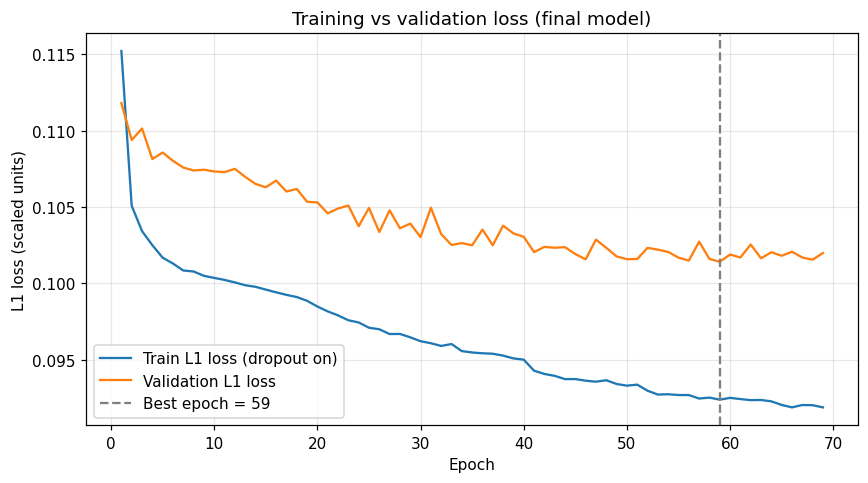

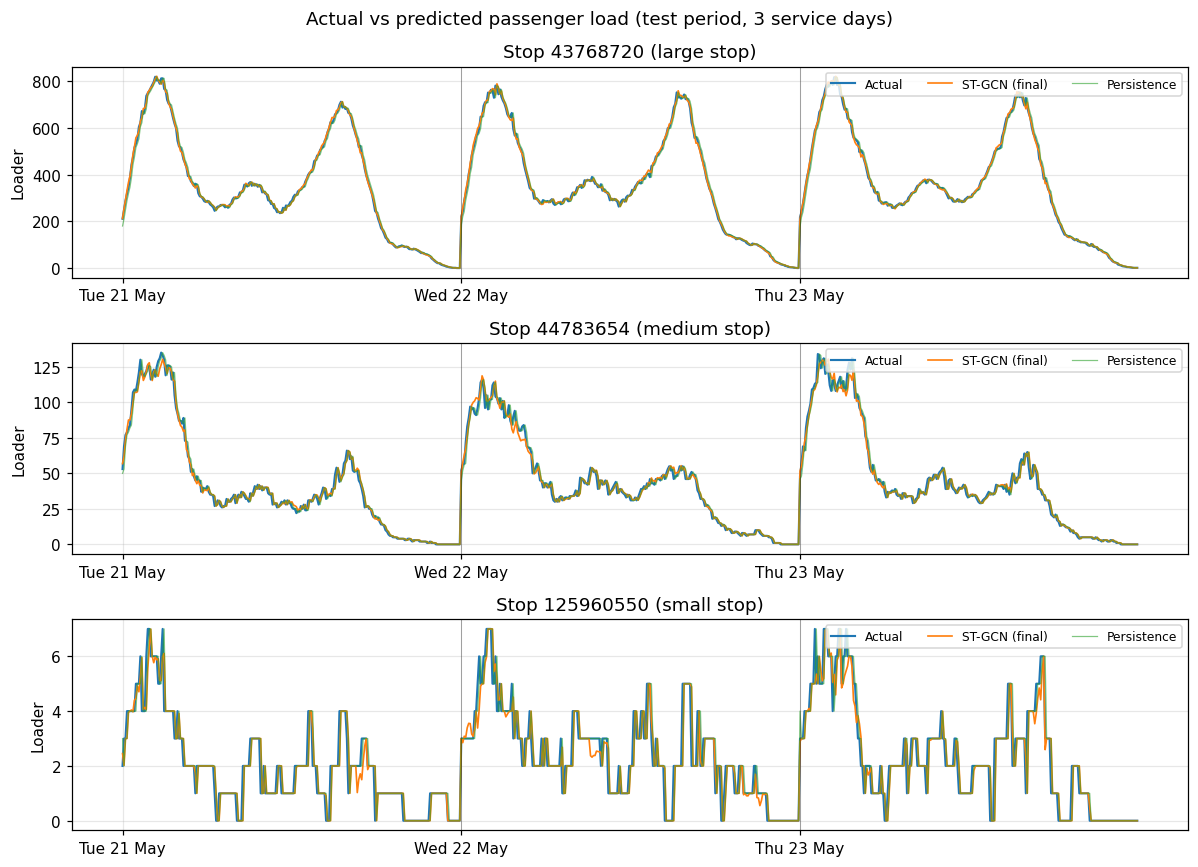

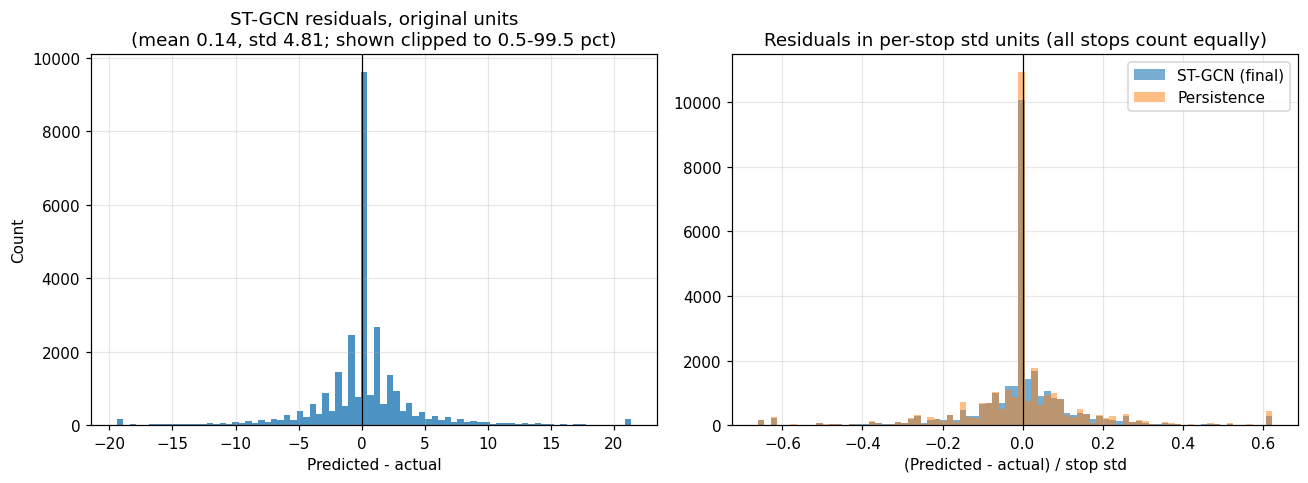

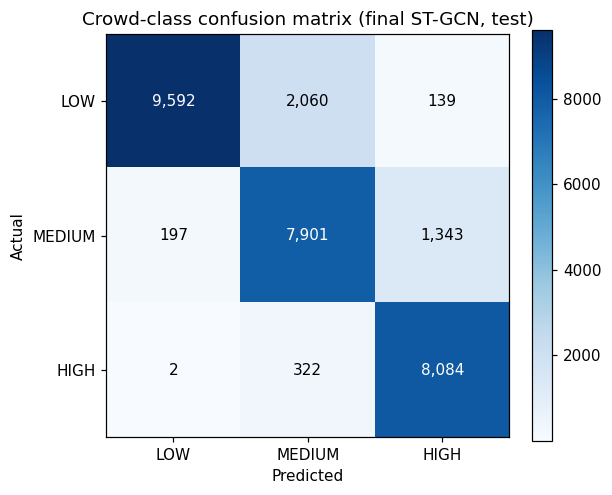

Saved: plot_loss_curves.png, plot_actual_vs_predicted.png, plot_residuals.png, plot_confusion_matrix.png
Saved: model_config.json, feature_config.json, scaler_params.csv

Residual summary (test, original units):
       res_final   res_pers
count  29640.000  29640.000
mean       0.140      0.163
std        4.805      6.274
min      -47.187    -68.000
25%       -1.000     -1.000
50%        0.000      0.000
75%        1.004      1.000
max       47.486     69.000


In [56]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

OUT = "/kaggle/working"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

hist = pd.read_csv(f"{OUT}/training_history.csv")
pred = pd.read_csv(f"{OUT}/predictions.csv", parse_dates=["timestamp"], dtype={"stop_id": str})
info = json.load(open(f"{OUT}/training_info.json"))
ckpt = torch.load(f"{OUT}/best_stgcn_crowd_model.pt", map_location="cpu", weights_only=False)
sp = np.load(f"{OUT}/split_and_scaler.npz")
mapping = pd.read_csv(f"{OUT}/stop_mapping.csv", dtype={"stop_id": str})
STOPS = mapping.sort_values("node_index")["stop_id"].tolist()
mu, sd = sp["mu"], sp["sd"]
best_ep = info["best_epoch"]

# ---------- 1) Loss curves ----------
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hist["epoch"], hist["train_loss"], label="Train L1 loss (dropout on)")
ax.plot(hist["epoch"], hist["val_loss"], label="Validation L1 loss")
ax.axvline(best_ep, color="gray", ls="--", label=f"Best epoch = {best_ep}")
ax.set_xlabel("Epoch"); ax.set_ylabel("L1 loss (scaled units)")
ax.set_title("Training vs validation loss (final model)"); ax.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/plot_loss_curves.png"); plt.show()

# ---------- 2) Actual vs predicted ----------
t0, t1 = pd.Timestamp("2024-05-21 05:00"), pd.Timestamp("2024-05-24 05:00")
show = ["43768720", "44783654", "125960550"]
names = {"43768720": "large stop", "44783654": "medium stop", "125960550": "small stop"}
fig, axes = plt.subplots(len(show), 1, figsize=(11, 8))
for ax, s in zip(axes, show):
    sub = pred[(pred["stop_id"] == s) & (pred["timestamp"] >= t0) & (pred["timestamp"] < t1)] \
            .sort_values("timestamp").reset_index(drop=True)
    x = np.arange(len(sub))
    ax.plot(x, sub["actual_load"], label="Actual", lw=1.4)
    ax.plot(x, sub["predicted_load"], label="ST-GCN (final)", lw=1.1)
    ax.plot(x, sub["persistence_load"], label="Persistence", lw=0.8, alpha=0.6)
    sdate = (sub["timestamp"] - pd.Timedelta(hours=5)).dt.normalize()
    starts = np.where(sdate.ne(sdate.shift()))[0]
    ax.set_xticks(starts); ax.set_xticklabels([sdate.iloc[i].strftime("%a %d %b") for i in starts])
    for i in starts[1:]:
        ax.axvline(i, color="k", lw=0.5, alpha=0.4)
    ax.set_title(f"Stop {s} ({names[s]})"); ax.set_ylabel("Loader")
    ax.legend(loc="upper right", ncol=3, fontsize=8)
fig.suptitle("Actual vs predicted passenger load (test period, 3 service days)")
plt.tight_layout(); plt.savefig(f"{OUT}/plot_actual_vs_predicted.png"); plt.show()

# ---------- 3) Residual distributions ----------
sd_map = dict(zip(STOPS, sd[:, 2]))
pred["res_final"] = pred["predicted_load"] - pred["actual_load"]
pred["res_pers"] = pred["persistence_load"] - pred["actual_load"]
pred["res_final_s"] = pred["res_final"] / pred["stop_id"].map(sd_map)
pred["res_pers_s"] = pred["res_pers"] / pred["stop_id"].map(sd_map)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
lo, hi = np.percentile(pred["res_final"], [0.5, 99.5])
axes[0].hist(pred["res_final"].clip(lo, hi), bins=80, color="tab:blue", alpha=0.8)
axes[0].axvline(0, color="k", lw=0.8)
axes[0].set_title(f"ST-GCN residuals, original units\n(mean {pred['res_final'].mean():.2f}, "
                  f"std {pred['res_final'].std():.2f}; shown clipped to 0.5-99.5 pct)")
axes[0].set_xlabel("Predicted - actual"); axes[0].set_ylabel("Count")
lo, hi = np.percentile(pred["res_final_s"], [0.5, 99.5])
bins = np.linspace(lo, hi, 80)
axes[1].hist(pred["res_final_s"].clip(lo, hi), bins=bins, alpha=0.6, label="ST-GCN (final)")
axes[1].hist(pred["res_pers_s"].clip(lo, hi), bins=bins, alpha=0.5, label="Persistence")
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_title("Residuals in per-stop std units (all stops count equally)")
axes[1].set_xlabel("(Predicted - actual) / stop std"); axes[1].legend()
plt.tight_layout(); plt.savefig(f"{OUT}/plot_residuals.png"); plt.show()

# ---------- 4) Confusion matrix ----------
cm = pd.read_csv(f"{OUT}/confusion_matrix_crowd_class.csv", index_col=0)
fig, ax = plt.subplots(figsize=(5.5, 4.8))
im = ax.imshow(cm.values, cmap="Blues"); ax.grid(False)
ax.set_xticks(range(3)); ax.set_xticklabels(["LOW", "MEDIUM", "HIGH"])
ax.set_yticks(range(3)); ax.set_yticklabels(["LOW", "MEDIUM", "HIGH"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Crowd-class confusion matrix (final ST-GCN, test)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm.values[i, j]:,}", ha="center", va="center",
                color="white" if cm.values[i, j] > cm.values.max() / 2 else "black")
plt.colorbar(im, fraction=0.046); plt.tight_layout()
plt.savefig(f"{OUT}/plot_confusion_matrix.png"); plt.show()

# ---------- config files ----------
hp, cfg = info["hyperparameters"], ckpt["config"]
model_config = {
    "model": "ST-GCN (2 ST blocks: gated temporal conv -> graph conv -> gated temporal conv, BatchNorm, Dropout)",
    "graph_conv": "A_mix @ X @ W, A_mix = s*A_hat + (1-s)*I; A_hat = fixed symmetric-normalised GTFS adjacency "
                  "with self-loops; s is learned per ST block (sigmoid of a parameter)",
    "learned_graph_mix_s_per_block": [round(v, 4) for v in ckpt["graph_mix_s"]],
    "output": "next-step loader for all nodes = last observed scaled loader + learned correction (residual)",
    "hidden_dim": cfg["hidden"], "temporal_kernel": cfg["kt"], "dropout": cfg["dropout"],
    "residual_output": cfg["residual"], "num_st_blocks": 2,
    "optimizer": "Adam", "learning_rate": hp["lr"], "weight_decay": hp["weight_decay"],
    "lr_scheduler": "ReduceLROnPlateau(factor=0.5, patience=4) on validation MAE_scaled",
    "loss": "L1 on per-stop standardised target", "grad_clip": hp["grad_clip"],
    "batch_size": hp["batch_size"], "max_epochs": hp["max_epochs"],
    "epochs_run": info["epochs_run"], "best_epoch": best_ep,
    "early_stopping_patience": hp["patience"],
    "early_stopping_and_checkpoint_criterion": "validation MAE_scaled (test set not used)",
    "input_sequence_length": int(sp["L"]), "input_minutes": int(sp["L"]) * 5,
    "prediction_horizon_steps": int(sp["H"]), "prediction_horizon_minutes": int(sp["H"]) * 5,
    "num_nodes": ckpt["num_nodes"], "num_features": ckpt["in_features"],
    "trainable_parameters": ckpt["n_params"], "seed": hp["seed"],
    "split": "chronological, by whole service days: 64 train / 14 val / 13 test",
    "window_counts": {"train": int(len(sp["train_starts"])), "val": int(len(sp["val_starts"])),
                      "test": int(len(sp["test_starts"]))},
    "selection_history": "first model (MSE, GTFS graph) was evaluated on test once; the final model "
                         "(L1, graph mix) was chosen using validation only, then evaluated on test. "
                         "The test set was therefore seen twice.",
}
json.dump(model_config, open(f"{OUT}/model_config.json", "w"), indent=2)

feature_config = {
    "input_features": ["boarding", "landing", "loader_prev", "hour_sin", "hour_cos",
                       "dow_sin", "dow_cos", "is_weekend"],
    "feature_notes": {
        "boarding": "estimated boardings at the stop in the 5-min slot (up to time t)",
        "landing": "estimated alightings at the stop in the 5-min slot (up to time t)",
        "loader_prev": "past occupancy values only (up to time t); the target slot t+1 is never an input",
        "time_features": "cyclical hour and service-day weekday, weekend flag; 00:00-00:55 belongs to the previous service day",
    },
    "target": "loader (estimated bus occupancy) at the stop, 5 minutes after the last input step",
    "scaling_method": "per-stop, per-feature standardisation (z-score), mean/std fitted on TRAIN service days only; "
                      "time features not scaled",
    "scaler_file": "scaler_params.csv",
    "post_processing": "predictions clipped at 0 (occupancy cannot be negative)",
    "crowd_classes": "per-stop terciles of TRAIN loader: LOW <= 33rd pct < MEDIUM <= 67th pct < HIGH (no capacity data)",
    "graph": "GTFS-based, nodes = stop_id; edges between consecutive crowd stops on each trip; log1p(trip count) "
             "weights; undirected; self-loops; D^-1/2 (A+I) D^-1/2",
}
json.dump(feature_config, open(f"{OUT}/feature_config.json", "w"), indent=2)

pd.DataFrame({"stop_id": STOPS,
              **{f"{f}_mean": mu[:, j] for j, f in enumerate(["boarding", "landing", "loader"])},
              **{f"{f}_std": sd[:, j] for j, f in enumerate(["boarding", "landing", "loader"])}}
             ).to_csv(f"{OUT}/scaler_params.csv", index=False)

print("Saved: plot_loss_curves.png, plot_actual_vs_predicted.png, plot_residuals.png, plot_confusion_matrix.png")
print("Saved: model_config.json, feature_config.json, scaler_params.csv")
print("\nResidual summary (test, original units):")
print(pred[["res_final", "res_pers"]].describe().round(3).to_string())

In [57]:
import json, os
import numpy as np
import pandas as pd

SAVED = "/kaggle/input/notebooks/mrithulavjmp/st-gcn-crowd-prediction-model"
WORK = "/kaggle/working"
DATA = "/kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2"

# ---------- file finder: WORK first, then the saved version ----------
def find(name):
    if os.path.exists(f"{WORK}/{name}"):
        return f"{WORK}/{name}"
    if os.path.exists(f"{SAVED}/{name}"):
        return f"{SAVED}/{name}"
    if os.path.isdir(SAVED):
        for dp, _, fns in os.walk(SAVED):
            if name in fns:
                return os.path.join(dp, name)
    return None

need = ["model_config.json", "feature_config.json", "training_info.json", "evaluation_metrics.csv",
        "test_model_comparison.csv", "wall_time.csv", "test_per_stop_metrics.csv", "test_per_day_metrics.csv",
        "stop_mapping.csv", "adjacency_raw_weights.npy", "prepared_arrays.npz", "training_history.csv"]
P = {n: find(n) for n in need}
missing = [n for n, p in P.items() if p is None]
print("File sources:")
for n, p in P.items():
    print(f"  {n:<28} {p if p else 'MISSING'}")
if missing:
    raise SystemExit(f"\nMissing files: {missing}\nRun Cell 13b, Cell 14 and Cell 15 first, then rerun this cell.")

mc = json.load(open(P["model_config.json"]))
fc = json.load(open(P["feature_config.json"]))
ti = json.load(open(P["training_info.json"]))
ev = pd.read_csv(P["evaluation_metrics.csv"]).set_index("metric")["value"]
cmp_df = pd.read_csv(P["test_model_comparison.csv"]).set_index("model")
wt = pd.read_csv(P["wall_time.csv"]).set_index("stage")["seconds"]
ps = pd.read_csv(P["test_per_stop_metrics.csv"], dtype={"stop": str})
pdy = pd.read_csv(P["test_per_day_metrics.csv"])
mapping = pd.read_csv(P["stop_mapping.csv"], dtype={"stop_id": str})
W = np.load(P["adjacency_raw_weights.npy"])
ts = pd.to_datetime(np.load(P["prepared_arrays.npz"], allow_pickle=True)["timestamps"])
hist = pd.read_csv(P["training_history.csv"])

# ---------- check these are the FINAL model's files ----------
if "ST-GCN final (L1, graph mix)" not in cmp_df.index or "MAE_final" not in ps.columns:
    raise SystemExit("\nThe test files are from the FIRST model (MSE). Run Cell 13b, then Cell 14, "
                     "then Cell 15, then rerun this cell.")

fin = cmp_df.loc["ST-GCN final (L1, graph mix)"]
first = cmp_df.loc["ST-GCN first (MSE, GTFS graph)"]
pers = cmp_df.loc["persistence"]
def imp(k): return 100 * (pers[k] - fin[k]) / pers[k]

best_ep = int(ti["best_epoch"])
tr_at_best = hist.loc[hist["epoch"] == best_ep, "train_loss"].iloc[0]
va_at_best = hist.loc[hist["epoch"] == best_ep, "val_loss"].iloc[0]
n_edges = int((W > 0).sum() // 2)
wc = mc["window_counts"]

print("\n" + "=" * 72)
print("FINAL MODEL SUMMARY: ST-GCN BUS CROWDING (LOADER) PREDICTION")
print("=" * 72)
print(f"Dataset path        : {DATA}")
print(f"Rows used           : {len(ts):,} timestamps x {mc['num_nodes']} stops (0 rows removed, no imputation)")
print(f"Date range          : {ts.min()} -> {ts.max()} (5-min slots; 01:00-04:55 nightly gap)")
print(f"Stops / nodes       : {mc['num_nodes']}")
print(f"Graph edges         : {n_edges} undirected (+ self-loops); isolated stop: "
      f"{mapping.loc[mapping['graph_degree'] == 0, 'stop_id'].tolist()}")
print(f"Features ({mc['num_features']})      : {', '.join(fc['input_features'])}")
print("Target              : loader (estimated occupancy), next 5 minutes")
print(f"Input length / horizon: {mc['input_sequence_length']} steps ({mc['input_minutes']} min) / "
      f"{mc['prediction_horizon_steps']} step ({mc['prediction_horizon_minutes']} min)")
print(f"Train/val/test windows: {wc['train']:,} / {wc['val']:,} / {wc['test']:,}  ({mc['split']})")
print(f"Best epoch          : {best_ep} of {ti['epochs_run']} run | trainable parameters: {mc['trainable_parameters']:,}")
print(f"Learned graph mix s : {mc['learned_graph_mix_s_per_block']}  (0 = identity, 1 = GTFS graph)")
print(f"Loss / optimiser    : {mc['loss']} / Adam (lr {mc['learning_rate']})")

print("\nTEST METRICS (final ST-GCN)")
print(f"  MAE   {ev['MAE']:.3f} | RMSE {ev['RMSE']:.3f} | MSE {ev['MSE']:.3f} | R2 {ev['R2']:.4f} "
      f"(mean per-stop R2 {ev['R2_mean_per_stop']:.4f})")
print(f"  MAPE  {ev['MAPE']:.2f} % on non-zero actuals only ({ev['MAPE_rows_used_pct']:.1f} % of rows) | "
      f"WAPE {ev['WAPE_pct']:.2f} % | MAE_scaled {ev['MAE_scaled']:.4f}")

print("\nBASELINE COMPARISON (test)")
print(cmp_df[["MAE", "RMSE", "MSE", "R2", "WAPE_%", "MAE_scaled"]].round(3).to_string())
print("\nFinal ST-GCN improvement over persistence (positive = better):")
for k in ["MAE", "RMSE", "MSE", "WAPE_%", "MAE_scaled"]:
    print(f"  {k:<11}: {imp(k):+.2f} %")
print(f"  Stops better than persistence (MAE): {int((ps['MAE_final'] < ps['MAE_persist']).sum())} of {len(ps)}")
print(f"  Days  better than persistence (MAE_scaled): "
      f"{int((pdy['MAE_scaled_final'] < pdy['MAE_scaled_persist']).sum())} of {len(pdy)}")
print(f"  First model (MSE, GTFS graph) vs persistence, MAE_scaled: "
      f"{100 * (pers['MAE_scaled'] - first['MAE_scaled']) / pers['MAE_scaled']:+.2f} %")

print("\nCROWD CLASSES (secondary; per-stop terciles of training loader)")
print(f"  Accuracy {ev['crowd_Accuracy']:.4f} | Precision {ev['crowd_Precision_macro']:.4f} | "
      f"Recall {ev['crowd_Recall_macro']:.4f} | F1 {ev['crowd_F1_macro']:.4f}  (macro; persistence accuracy is higher)")

print("\nWALL TIME (s)")
for k in ["preprocessing", "training", "evaluation", "inference"]:
    print(f"  {k:<14}: {wt[k]:.3f}")
print(f"\nModel file          : {WORK}/best_stgcn_crowd_model.pt")

print(f"""
{'=' * 72}
EXPLANATIONS
{'=' * 72}
1. Inputs used
   Per stop and 5-min slot, over the past 60 minutes: boarding, landing, past loader, plus
   hour (sin/cos), service-day weekday (sin/cos) and a weekend flag. All values are known at
   the last input time. The target slot is never an input.

2. Target predicted
   Loader (estimated bus occupancy) at each of the 10 stops, 5 minutes after the last input.
   The model outputs the last loader value plus a learned correction.

3. How the GTFS graph was built
   For each trip, stops are ordered by stop_sequence. Consecutive crowd stops on a trip are
   linked (A->B->C gives A-B and B-C), with other stops in between ignored, because only 1
   direct stop-to-stop edge exists among the 10 stops. Edge weight is log1p(number of trips),
   scaled to (0,1]. The graph is undirected, has self-loops and is normalised D^-1/2 (A+I) D^-1/2.
   The full GTFS has 2,867 stops, but only these 10 have crowd data.

4. Why a chronological split
   Future data must never help predict the past. Whole service days were split in time order
   (64 train / 14 val / 13 test) so that overlapping windows never sit in two splits. The scaler
   was fitted on training days only.

5. Overfitting
   Mild. At the best epoch the train L1 was {tr_at_best:.4f} and the validation L1 {va_at_best:.4f}
   (train is measured with dropout on). Early stopping and the best-epoch checkpoint on
   validation limited it. The first model (MSE) overfit slightly more.

6. Known limitations
   - Only 10 stops, 13 graph edges and one isolated stop. This is a small graph.
   - The GTFS graph adds little: the model learned s of about 0.07-0.11 (mostly self-connection),
     and an identity-graph version tied it on validation (0.1011 vs 0.1013). The gain over
     persistence comes mainly from the temporal part and the L1 loss, not from spatial links.
   - The GTFS calendar covers 2024-05-21 to 2024-06-21, but the data runs from March to May, so
     the graph is a static approximation of the network.
   - Loader is an estimate (boarding from AVL/AFC, alighting from trip chaining), not a direct count.
   - Boarding/landing are nearly zero at 3 stops; gains there are tiny in absolute terms.
   - Crowd classes are worse than persistence (no bus capacity available; terciles used).
   - The test set was looked at twice: once for the first model, and once for the final model,
     which was chosen using validation only. It is not a perfectly untouched test result.
   - One training seed for the final model; only 91 days of data; 2024-05-26 and 2024-05-30 were
     not better than persistence. Holiday effects are not modelled.
   - Only a 5-minute horizon was evaluated.

7. Files saved
""")
keep = ["best_stgcn_crowd_model.pt", "evaluation_metrics.csv", "wall_time.csv", "training_history.csv",
        "predictions.csv", "model_config.json", "feature_config.json", "stop_mapping.csv",
        "adjacency_matrix.npy", "adjacency_raw_weights.npy", "scaler_params.csv", "split_and_scaler.npz",
        "prepared_arrays.npz", "baseline_metrics.csv", "test_model_comparison.csv", "test_per_stop_metrics.csv",
        "test_per_day_metrics.csv", "confusion_matrix_crowd_class.csv", "plot_loss_curves.png",
        "plot_actual_vs_predicted.png", "plot_residuals.png", "plot_confusion_matrix.png"]
for f in keep:
    where = "working" if os.path.exists(f"{WORK}/{f}") else ("saved version" if find(f) else None)
    print(f"   {('OK (' + where + ')') if where else 'MISSING':<20} {f}")
print("   Also: *_v1* files (first model), training_info.json, preprocessing_time.json")

File sources:
  model_config.json            /kaggle/working/model_config.json
  feature_config.json          /kaggle/working/feature_config.json
  training_info.json           /kaggle/working/training_info.json
  evaluation_metrics.csv       /kaggle/working/evaluation_metrics.csv
  test_model_comparison.csv    /kaggle/working/test_model_comparison.csv
  wall_time.csv                /kaggle/working/wall_time.csv
  test_per_stop_metrics.csv    /kaggle/working/test_per_stop_metrics.csv
  test_per_day_metrics.csv     /kaggle/working/test_per_day_metrics.csv
  stop_mapping.csv             /kaggle/working/stop_mapping.csv
  adjacency_raw_weights.npy    /kaggle/working/adjacency_raw_weights.npy
  prepared_arrays.npz          /kaggle/working/prepared_arrays.npz
  training_history.csv         /kaggle/working/training_history.csv

FINAL MODEL SUMMARY: ST-GCN BUS CROWDING (LOADER) PREDICTION
Dataset path        : /kaggle/input/datasets/mrithulavjmp/crowd-prediction/Model2
Rows used           : 2